In [372]:
import pandas as pd
import glob
import os
pd.set_option('display.max_colwidth', None)

In [374]:
episode_1771 = episodes_data[episodes_data['episode_id'] == 1771]
episode_1771['mp3url']

1770    https://anchor.fm/s/241d34a8/podcast/play/15146373/https%3A%2F%2Fd3ctxlq1ktw2nl.cloudfront.net%2Fstaging%2F2020-06-13%2Ff49c487669b229c20ce4f7248f624f6e.m4a
Name: mp3url, dtype: object

In [179]:
pd.reset_option('display.max_colwidth')

### Racial justice segments in episode 1

In [266]:
episode_1_data = pd.read_csv("../data/episodes/part_1/episode_1.csv")
episode_1_data[(episode_1_data['racialJustice'] == 1) & (episode_1_data['collectiveAction'] == 0)]

,sentence,classification,annotator1,annotator2,annotator3,collectiveAction,racialJustice,collectiveActionMulti
21,"So my mother back in 1978, created a private s...",NaN,NaN,NaN,NaN,0,1,2.0
24,"My father, who's a mental health professional,...",NaN,NaN,NaN,NaN,0,1,3.0
106,"And I think that the 70s, 80s was really that ...",NaN,NaN,NaN,NaN,0,1,0.0
446,"Well, and I'm gonna say too that if we problem...",NaN,NaN,NaN,NaN,0,1,0.0


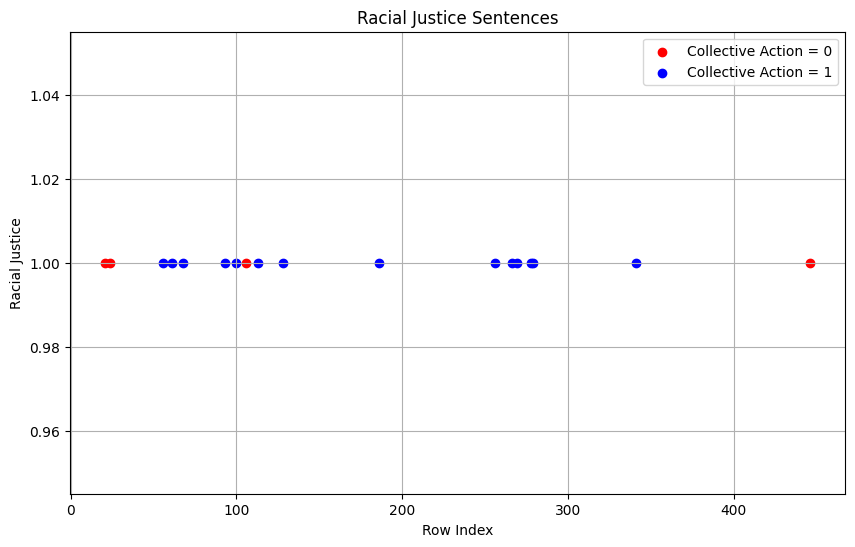

In [271]:
import matplotlib.pyplot as plt

# Filter the data
racial_justice_data = episode_1_data[episode_1_data['racialJustice'] == 1]
collective_action_0 = racial_justice_data[racial_justice_data['collectiveAction'] == 0]
collective_action_1 = racial_justice_data[racial_justice_data['collectiveAction'] == 1]

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(collective_action_0.index, collective_action_0['racialJustice'], color='red', label='Collective Action = 0')
plt.scatter(collective_action_1.index, collective_action_1['racialJustice'], color='blue', label='Collective Action = 1')
plt.xlabel('Row Index')
plt.ylabel('Racial Justice')
plt.title('Racial Justice Sentences')
plt.legend()
plt.grid(True)
plt.show()

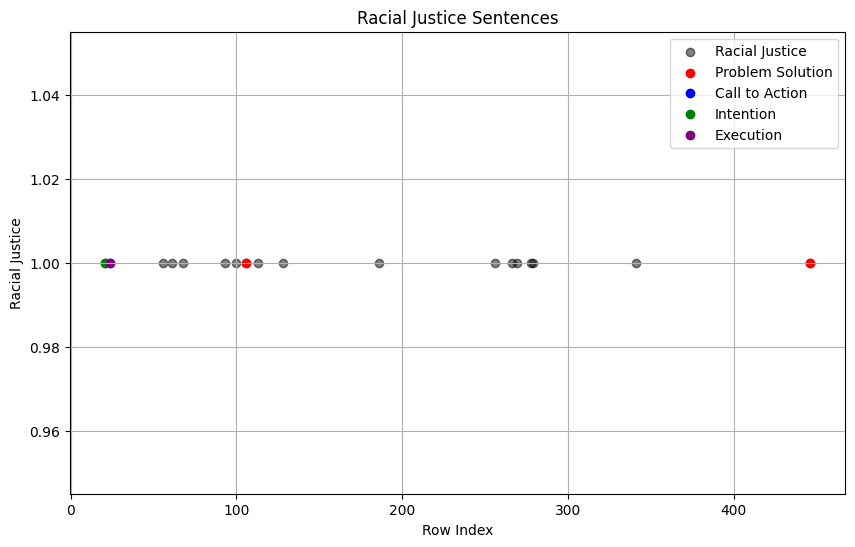

In [272]:
import matplotlib.pyplot as plt

# Filter the data
racial_justice_data = episode_1_data[episode_1_data['racialJustice'] == 1]

# Subset data for different collective action levels
problem_solution = racial_justice_data[racial_justice_data['collectiveActionMulti'] == 0]
call_to_action = racial_justice_data[racial_justice_data['collectiveActionMulti'] == 1]
intention = racial_justice_data[racial_justice_data['collectiveActionMulti'] == 2]
execution = racial_justice_data[racial_justice_data['collectiveActionMulti'] == 3]

# Plot the data
plt.figure(figsize=(10, 6))

# Plot all racial justice points in black
plt.scatter(racial_justice_data.index, racial_justice_data['racialJustice'], color='black', alpha=0.5, label='Racial Justice')

# Plot points for different collectiveActionMulti values
plt.scatter(problem_solution.index, problem_solution['racialJustice'], color='red', label='Problem Solution')
plt.scatter(call_to_action.index, call_to_action['racialJustice'], color='blue', label='Call to Action')
plt.scatter(intention.index, intention['racialJustice'], color='green', label='Intention')
plt.scatter(execution.index, execution['racialJustice'], color='purple', label='Execution')

plt.xlabel('Row Index')
plt.ylabel('Racial Justice')
plt.title('Racial Justice Sentences')
plt.legend()
plt.grid(True)
plt.show()

In [277]:
blm_episodes = pd.read_csv("../data/blm_episodes.csv") # based on LDA

In [279]:
import pandas as pd

# Ensure blm_episodes DataFrame is loaded
blm_episodes = pd.read_csv("../data/blm_episodes.csv")

# Group by 'category1' and select a random episode from each group
random_episodes = blm_episodes.groupby('category1').apply(lambda x: x.sample(1)).reset_index(drop=True)

# Display the selected random episodes
len(random_episodes)

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_87000/4099752115.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  random_episodes = blm_episodes.groupby('category1').apply(lambda x: x.sample(1)).reset_index(drop=True)


19

/Users/theodoramoldovan/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


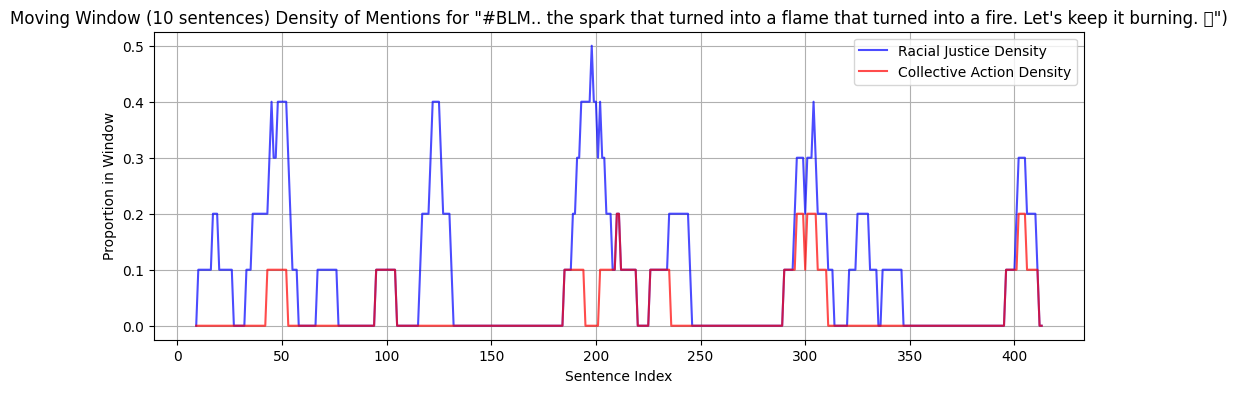

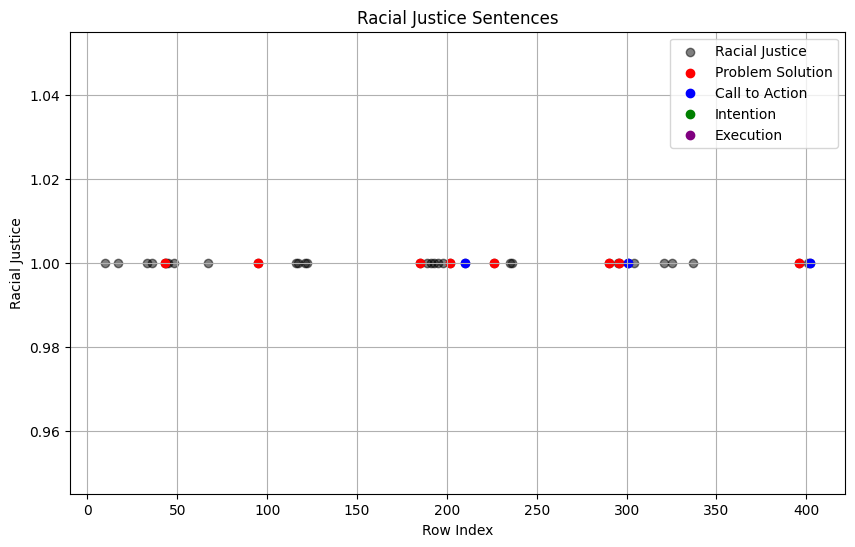

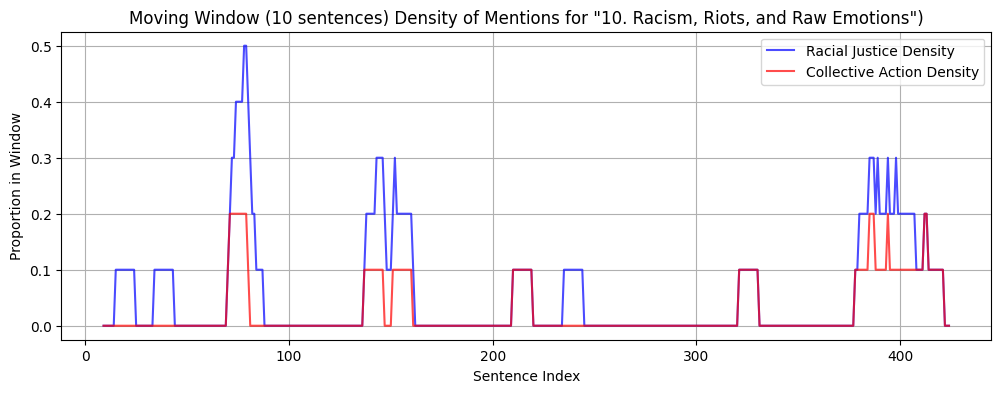

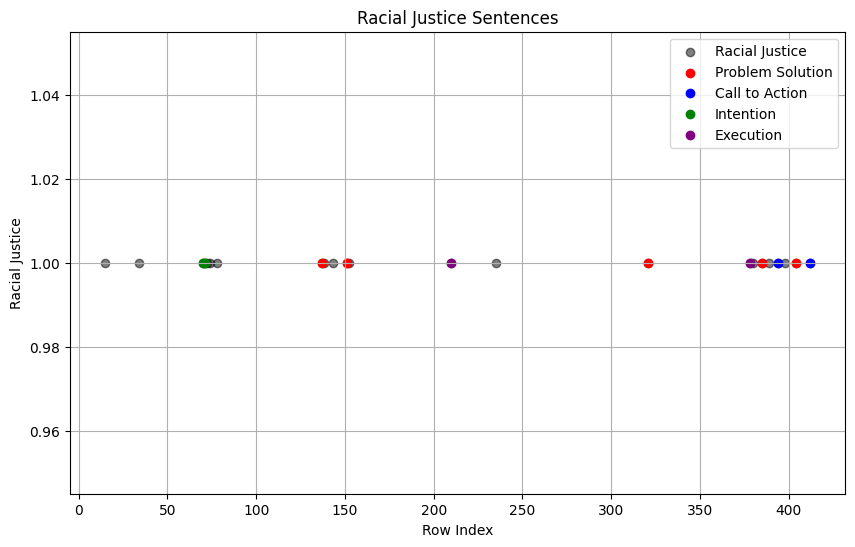

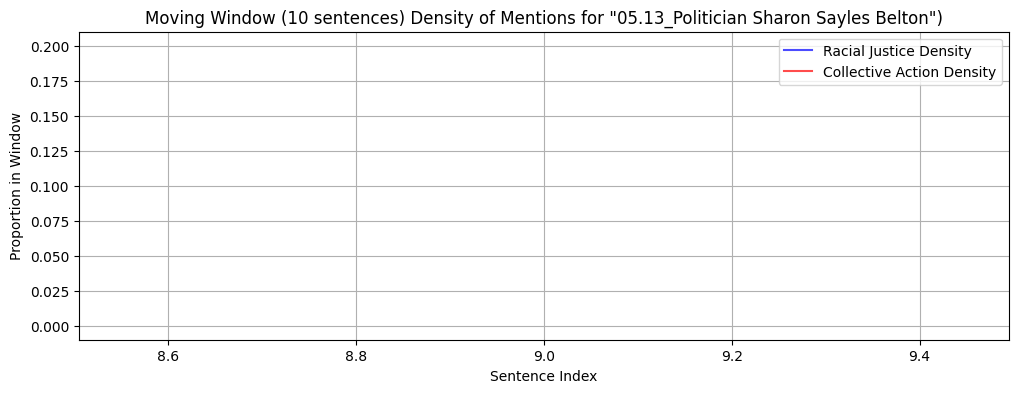

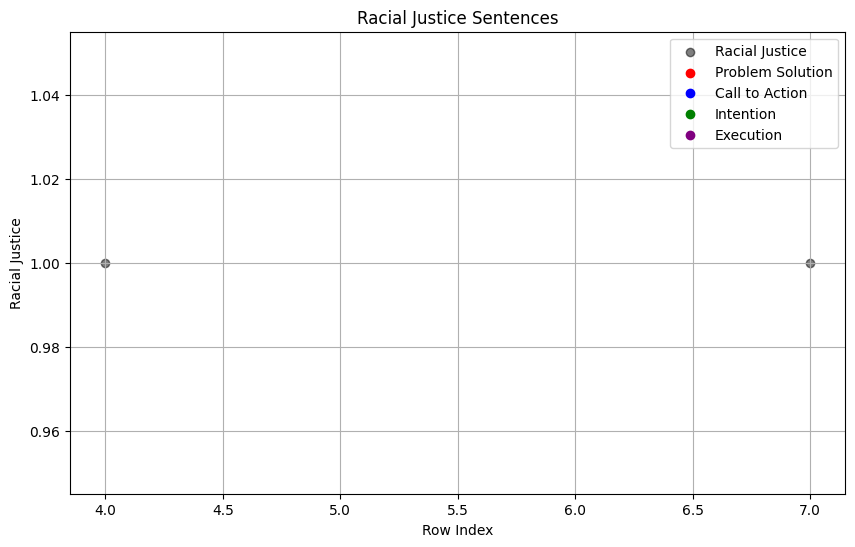

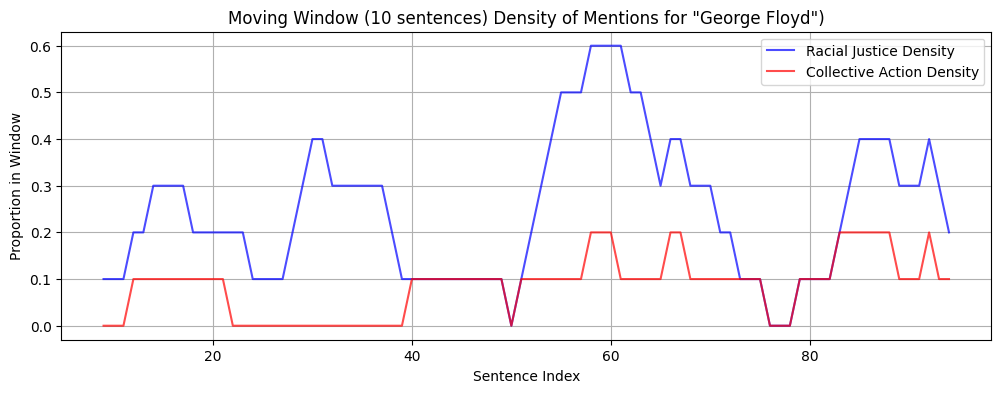

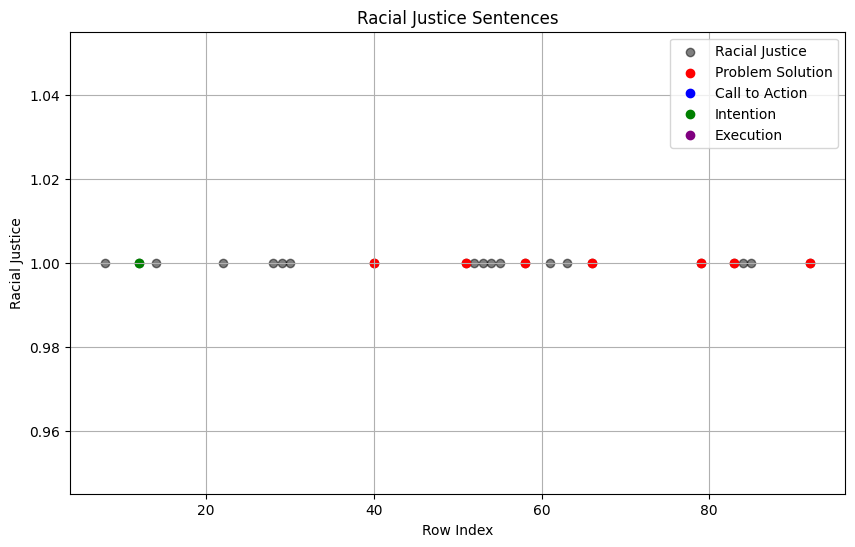

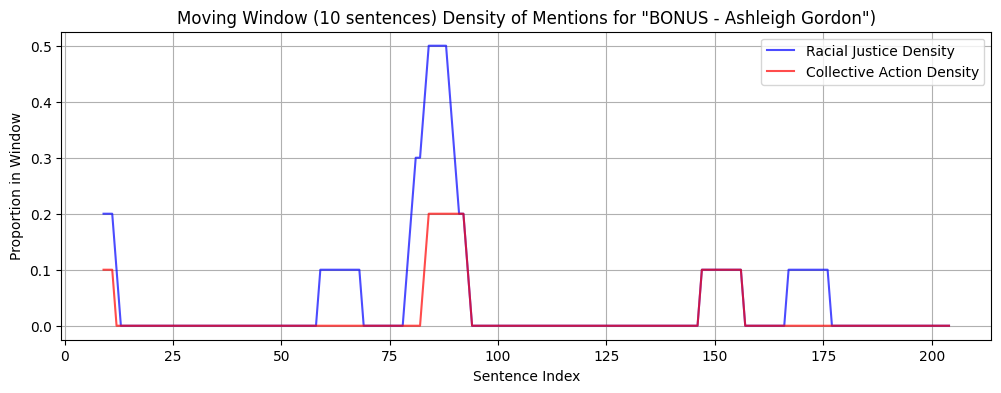

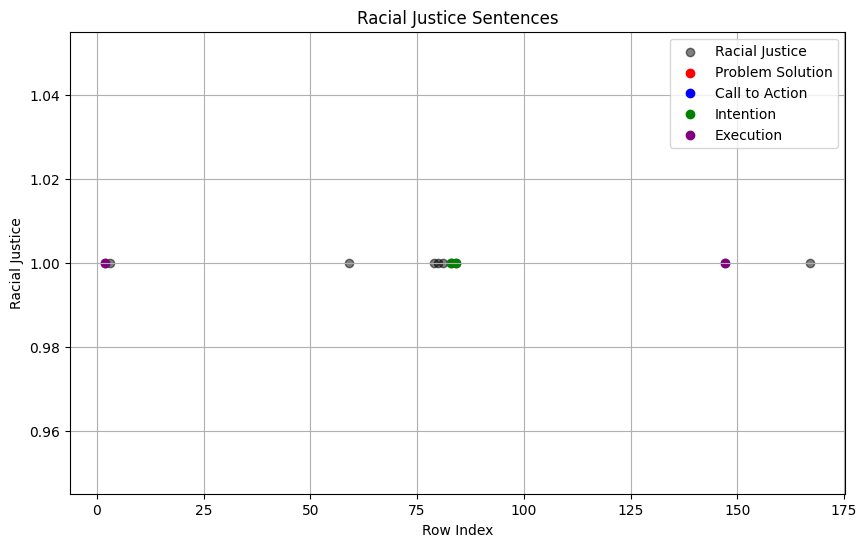

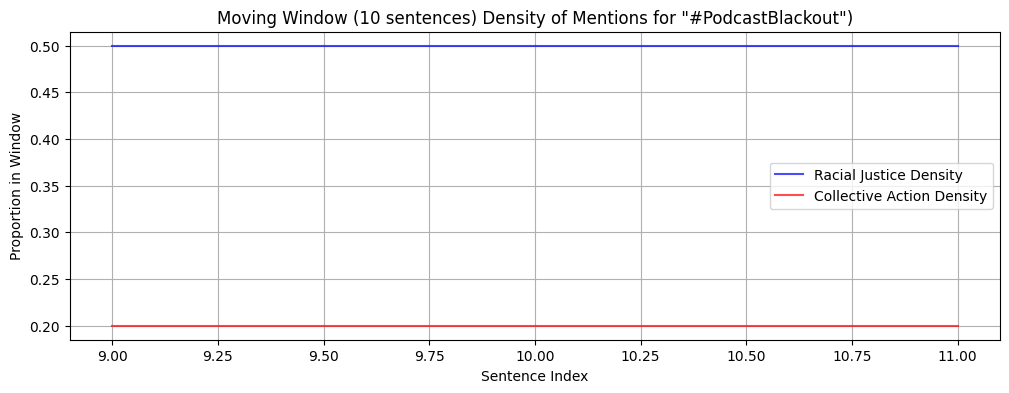

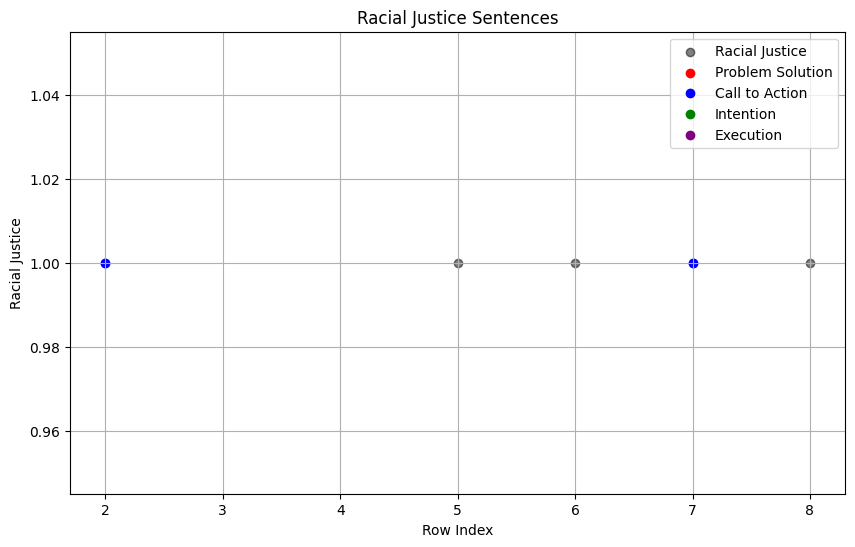

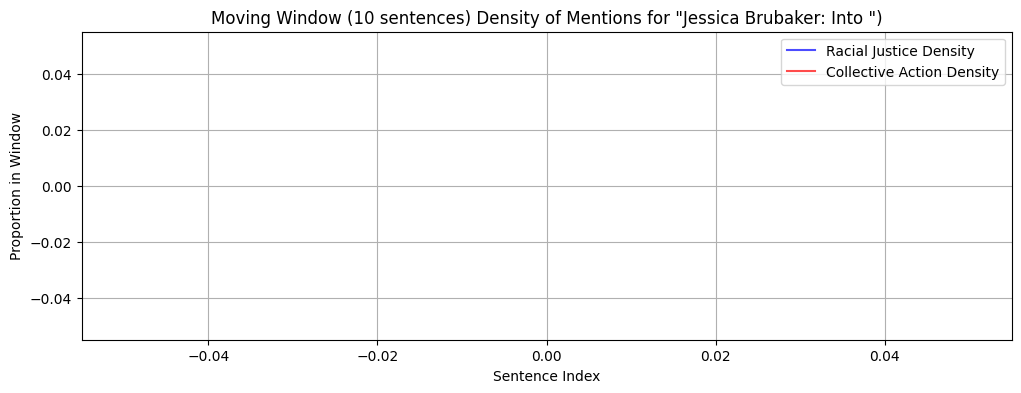

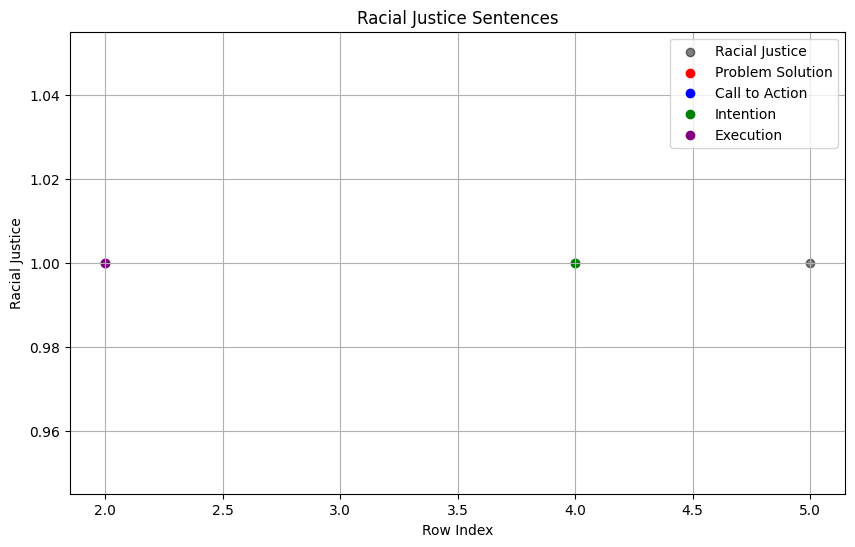

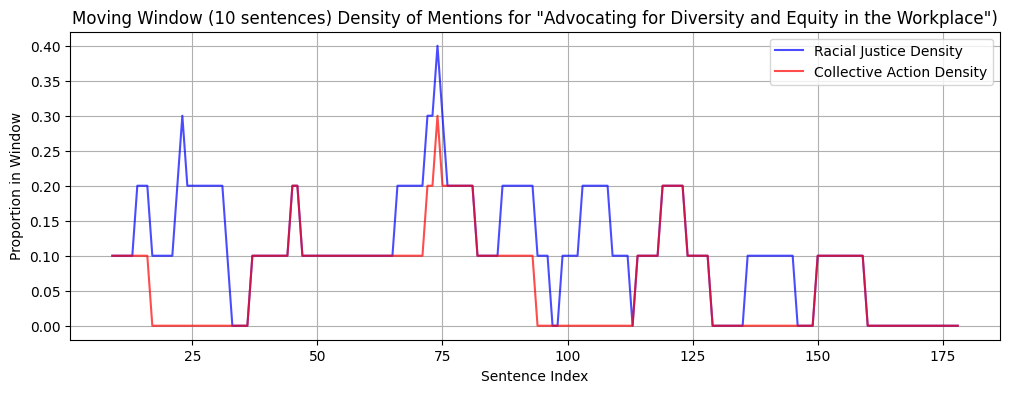

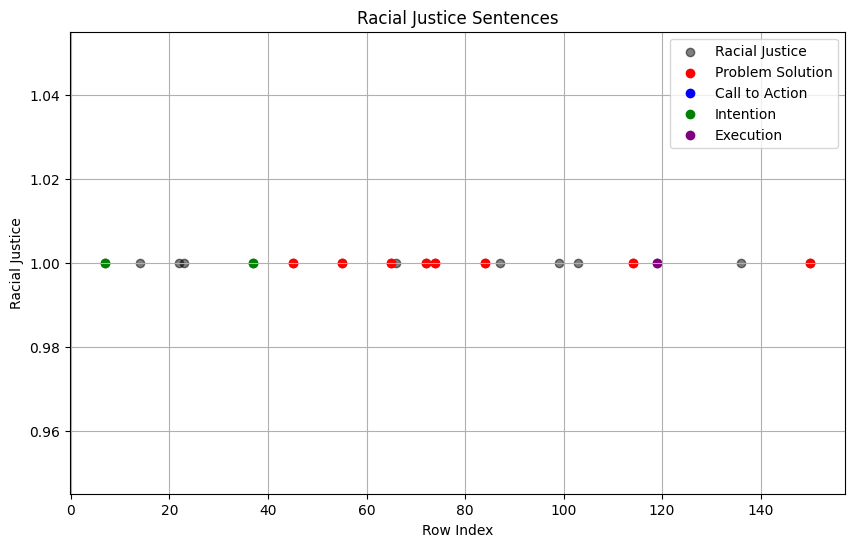

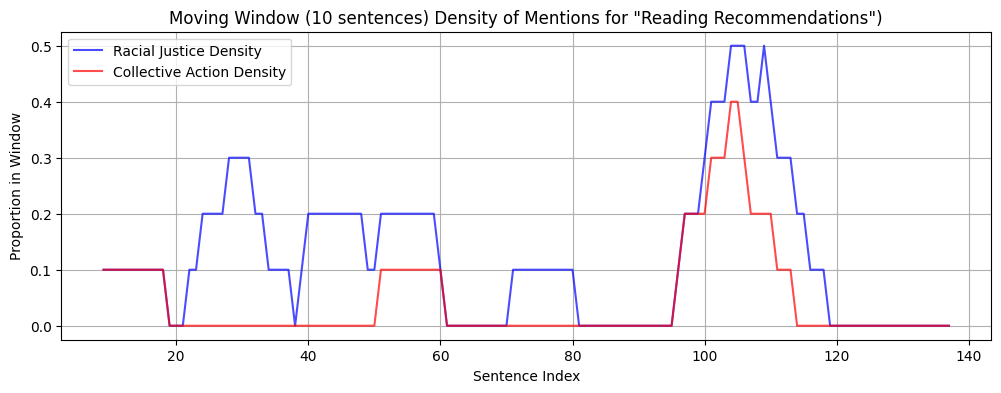

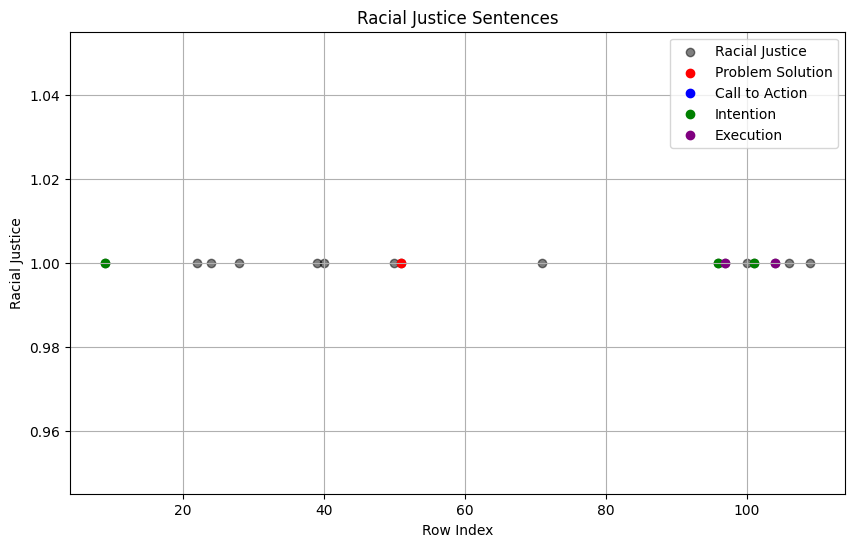

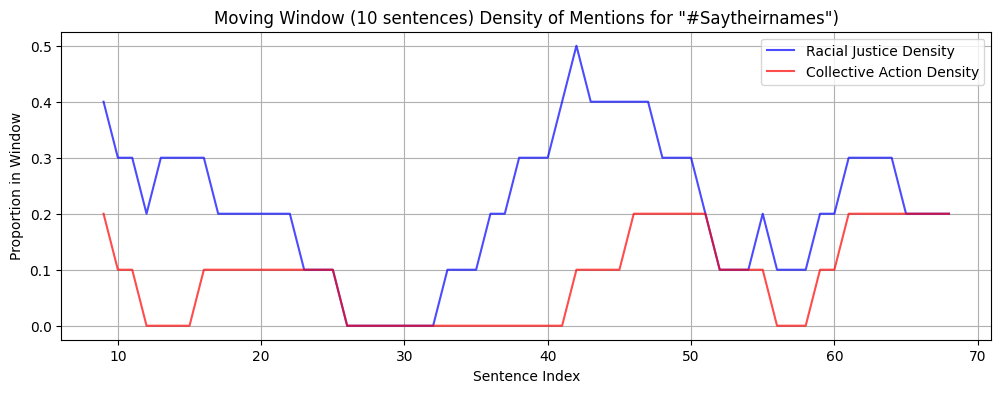

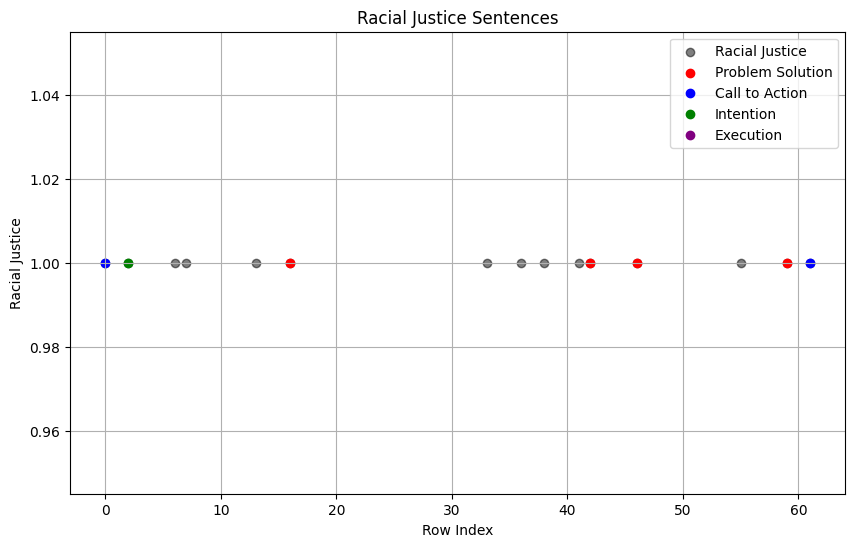

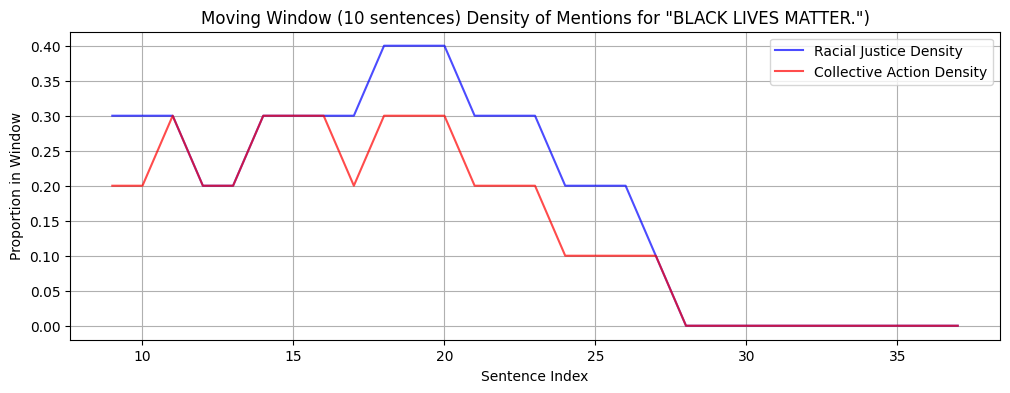

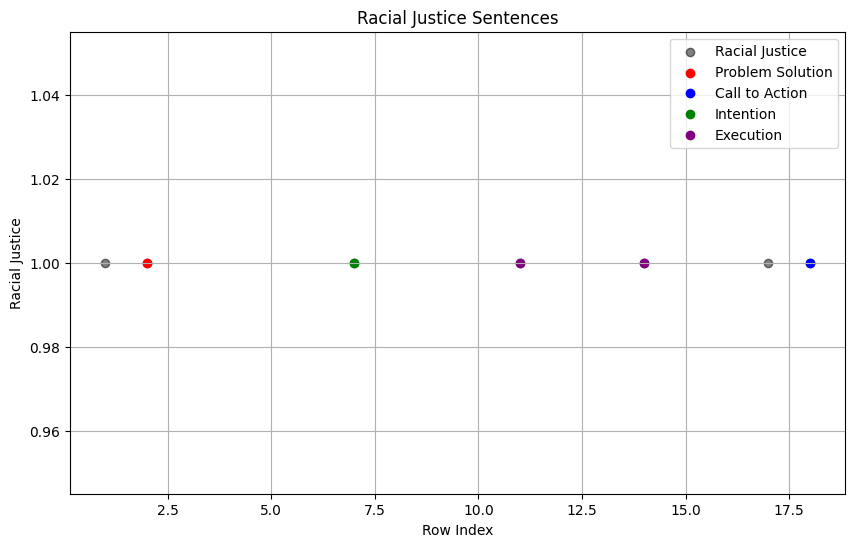

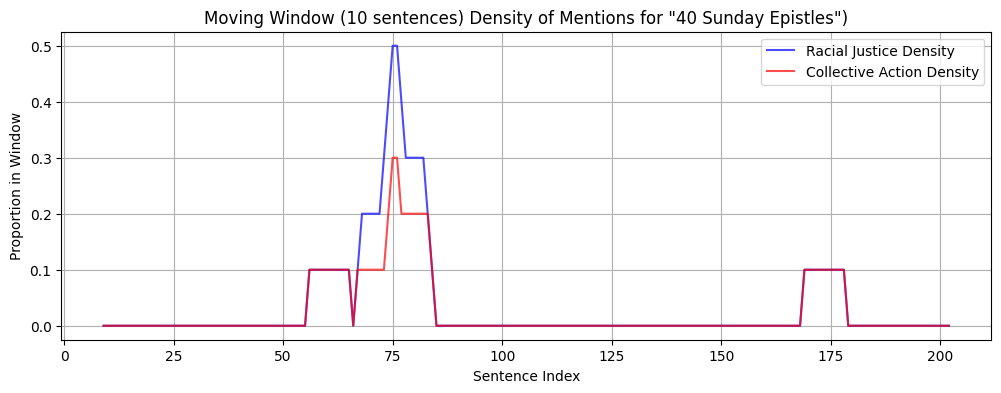

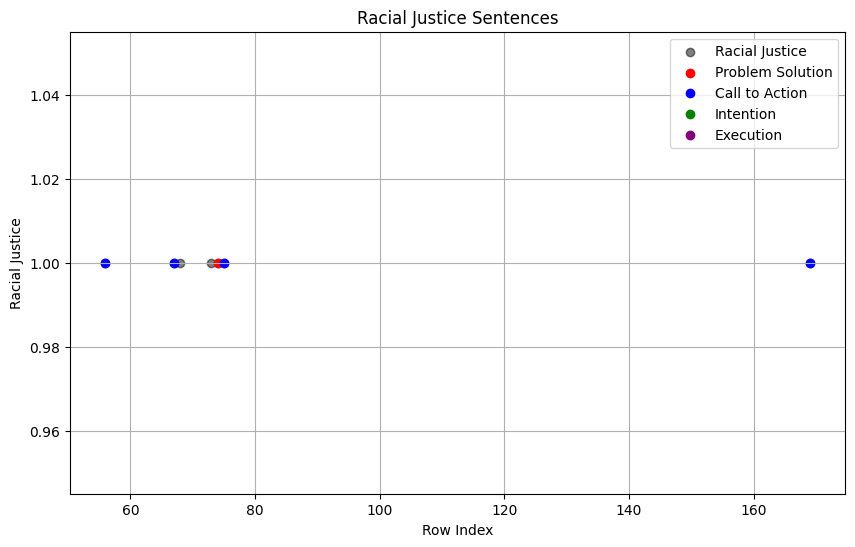

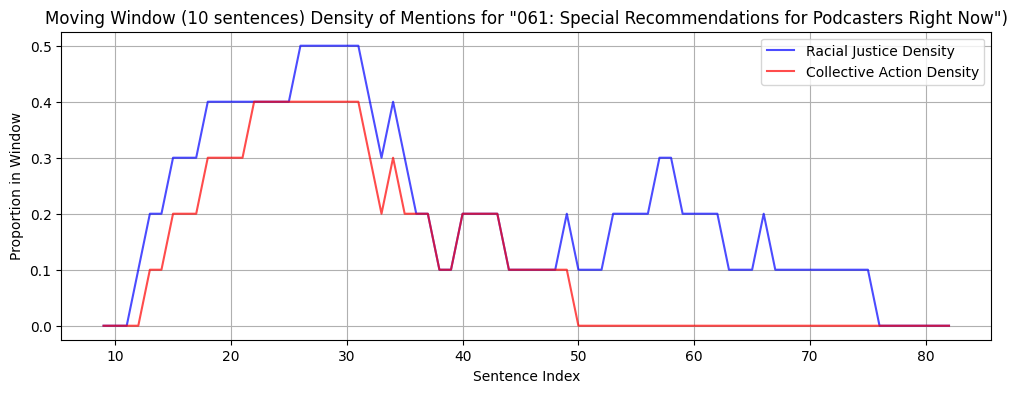

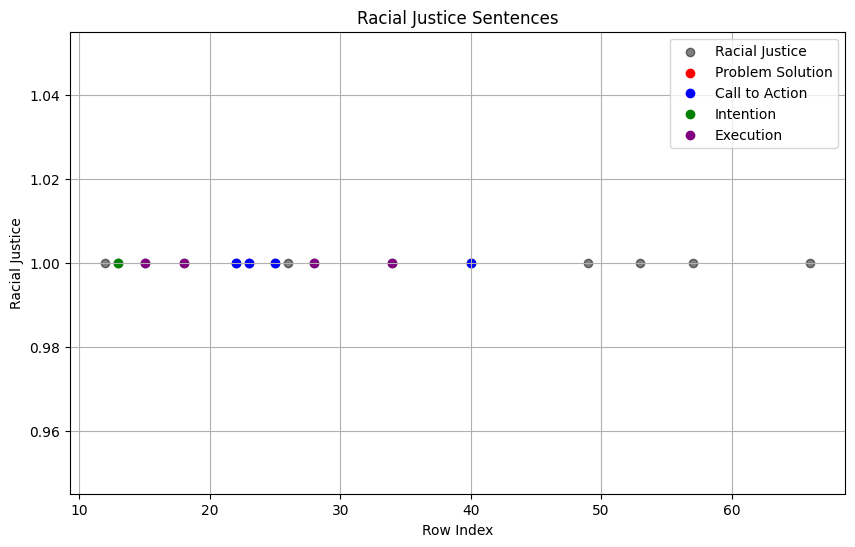

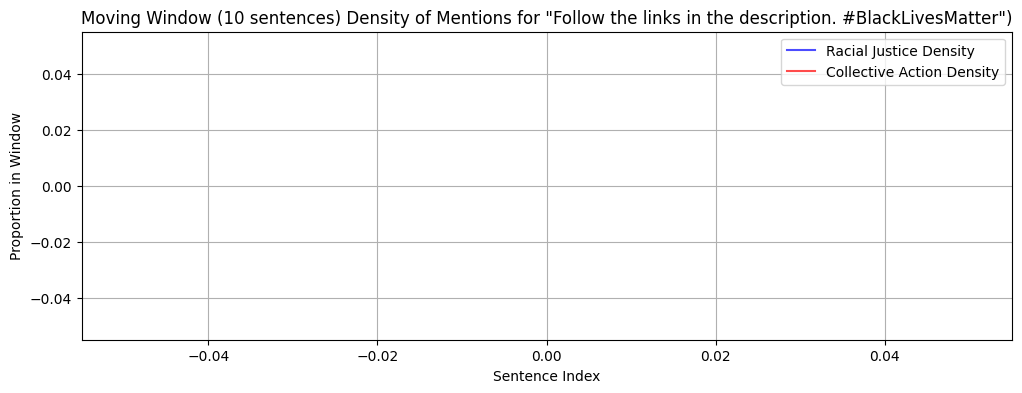

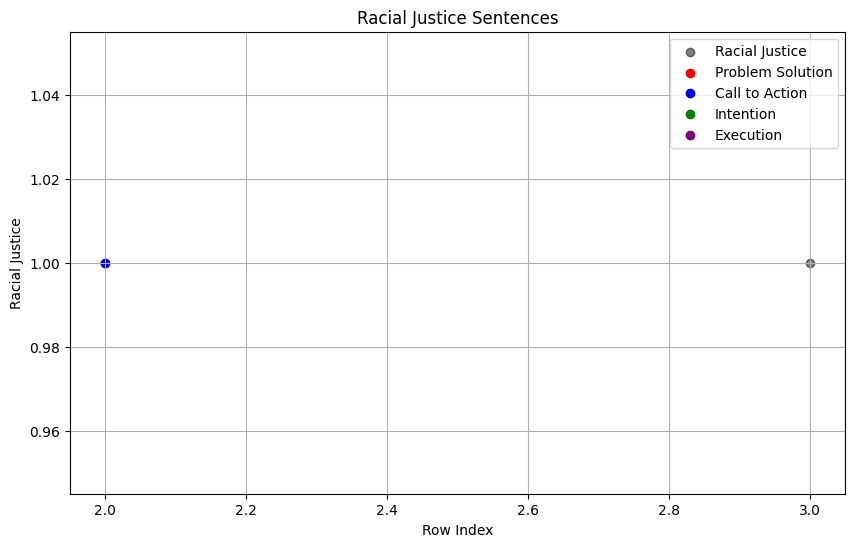

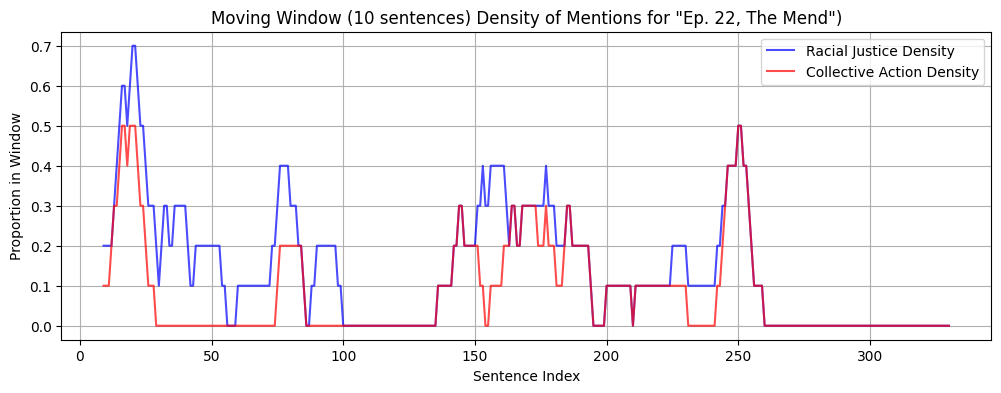

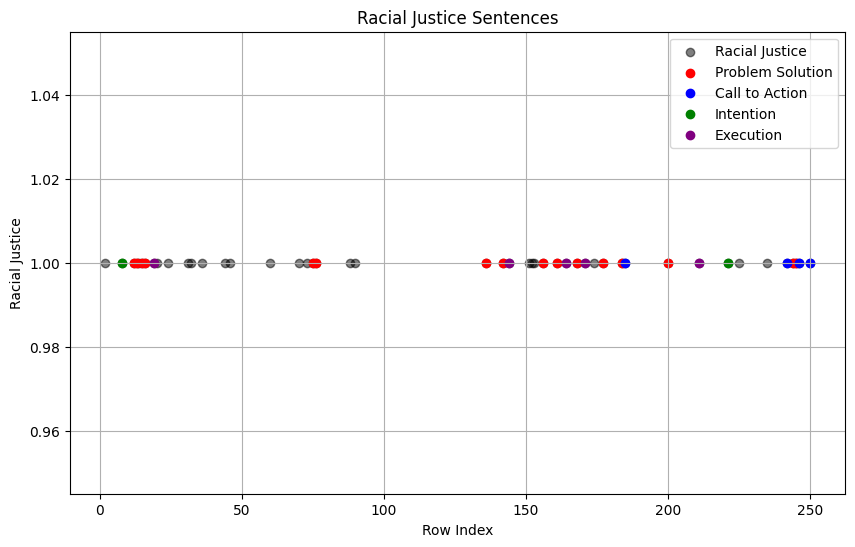

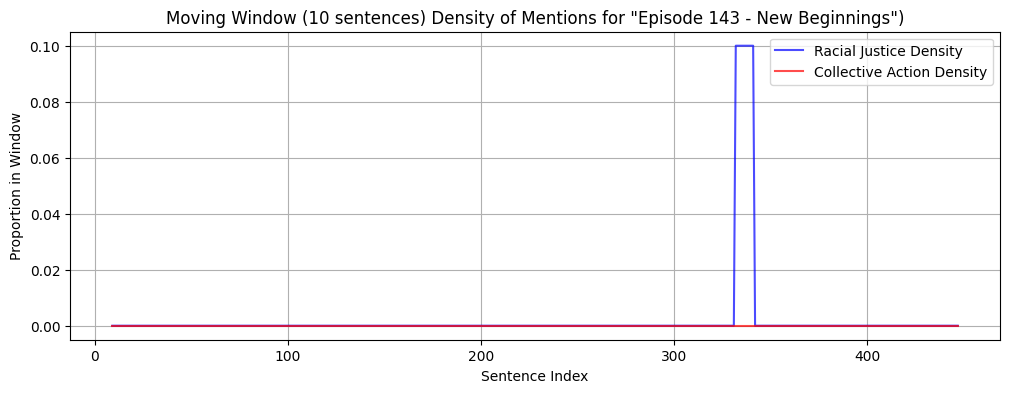

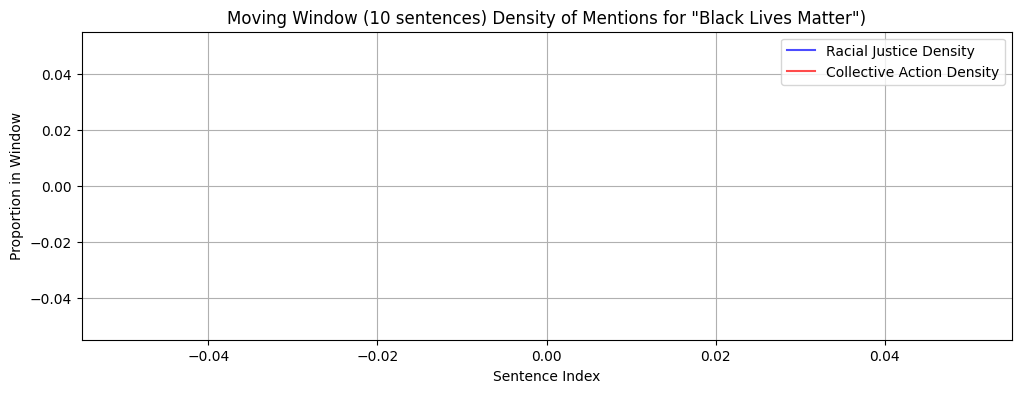

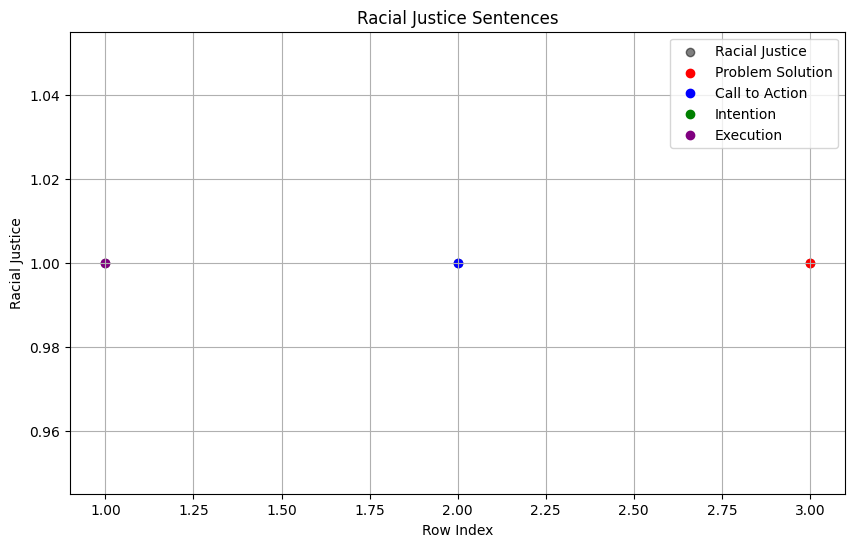

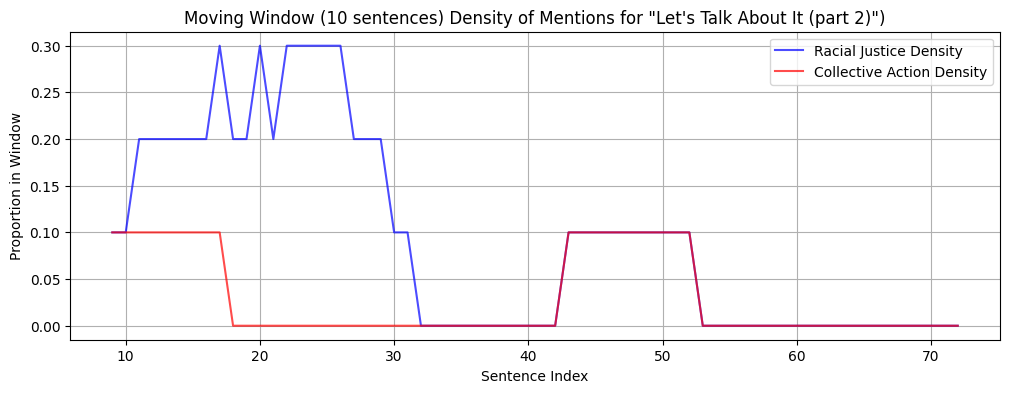

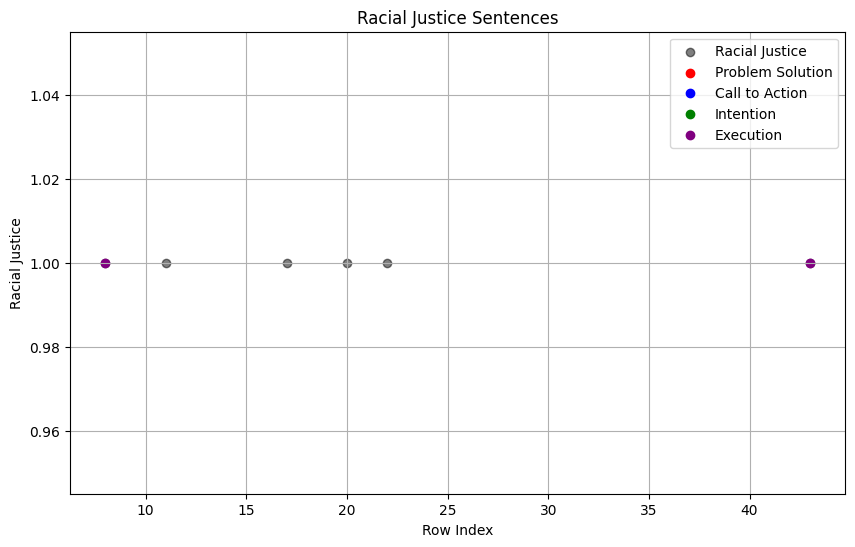

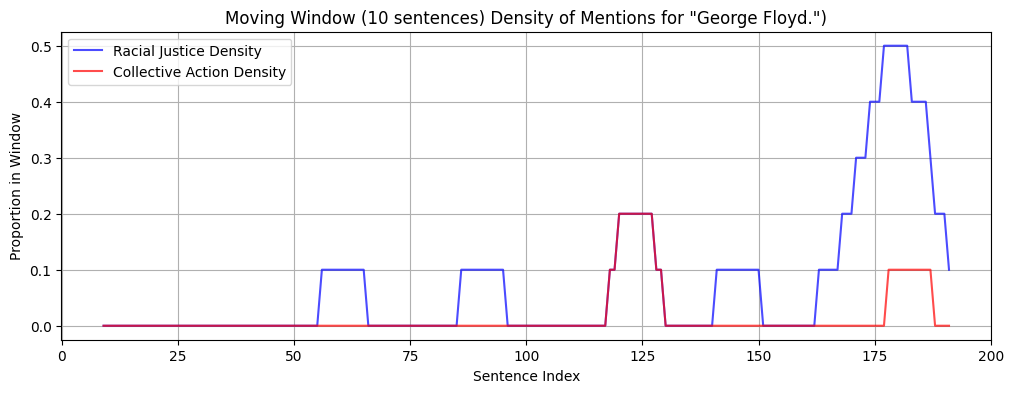

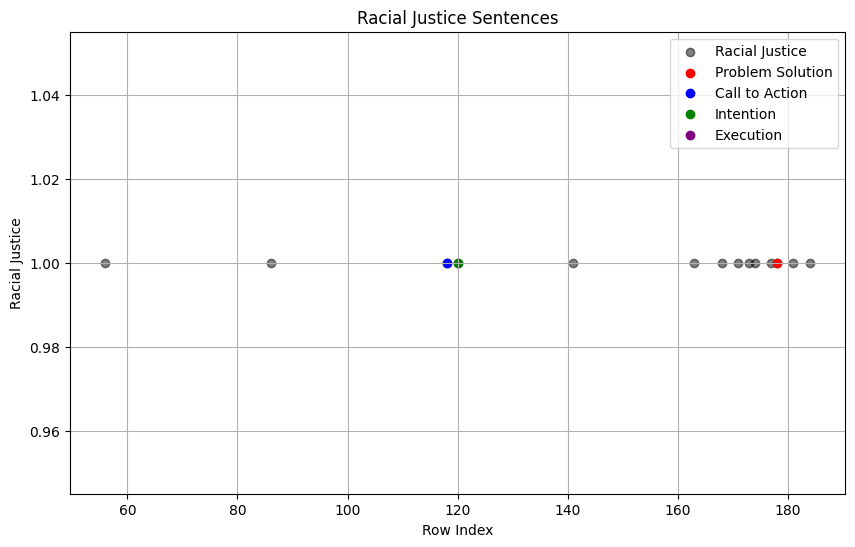

In [289]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define window size for rolling mean
window_size = 10  # Number of sentences to smooth over

# Get the list of valid episode filenames
valid_filenames = {f"episode_{eid}.csv" for eid in random_episodes['episode_id']}

# Loop through all CSV files in filtered_files
for file_path in filtered_files:
    # Extract the filename from the path
    filename = os.path.basename(file_path)
    
    # Check if the filename is in the list of valid filenames
    if filename in valid_filenames:
        # Load the CSV file into a DataFrame
        episode_data = pd.read_csv(file_path)
        
        # Retrieve episode title and podcast title
        episode_id = filename.split('_')[1].split('.')[0]  # Extract episode_id from filename
        epTitle = random_episodes.loc[random_episodes['episode_id'] == int(episode_id), 'epTitle'].values[0]
        podTitle = random_episodes.loc[random_episodes['episode_id'] == int(episode_id), 'podTitle'].values[0]
        
        # Define racialJustice and collectiveAction conditions
        racial_justice = episode_data['racialJustice'] == 1
        collective_action = (episode_data['racialJustice'] == 1) & (episode_data['collectiveAction'] == 0)
        
        # Calculate rolling mean for racial justice and collective action based on the conditions
        rolling_rj = racial_justice.rolling(window=window_size).mean()
        rolling_ca = collective_action.rolling(window=window_size).mean()
        
        # Plot rolling mean results
        plt.figure(figsize=(12, 4))
        plt.plot(rolling_rj, label='Racial Justice Density', color='blue', alpha=0.7)
        plt.plot(rolling_ca, label='Collective Action Density', color='red', alpha=0.7)
        plt.xlabel('Sentence Index')
        plt.ylabel('Proportion in Window')
        plt.title(f'Moving Window ({window_size} sentences) Density of Mentions for "{epTitle}")')
        plt.legend()
        plt.grid(True)
        plt.show()
        
        # Proceed only if 'collectiveActionMulti' column exists
        if 'collectiveActionMulti' in episode_data.columns:
            # Filter the data for racial justice mentions
            racial_justice_data = episode_data[episode_data['racialJustice'] == 1]
            
            # Subset data for different collective action levels
            problem_solution = racial_justice_data[racial_justice_data['collectiveActionMulti'] == 0]
            call_to_action = racial_justice_data[racial_justice_data['collectiveActionMulti'] == 1]
            intention = racial_justice_data[racial_justice_data['collectiveActionMulti'] == 2]
            execution = racial_justice_data[racial_justice_data['collectiveActionMulti'] == 3]
            
            # Plot scatter plot of racial justice mentions
            plt.figure(figsize=(10, 6))
            plt.scatter(racial_justice_data.index, racial_justice_data['racialJustice'], color='black', alpha=0.5, label='Racial Justice')
            plt.scatter(problem_solution.index, problem_solution['racialJustice'], color='red', label='Problem Solution')
            plt.scatter(call_to_action.index, call_to_action['racialJustice'], color='blue', label='Call to Action')
            plt.scatter(intention.index, intention['racialJustice'], color='green', label='Intention')
            plt.scatter(execution.index, execution['racialJustice'], color='purple', label='Execution')
            
            plt.xlabel('Row Index')
            plt.ylabel('Racial Justice')
            plt.title('Racial Justice Sentences')
            plt.legend()
            plt.grid(True)
            plt.show()


Rolling Sentence Window (For a Single Episode!)

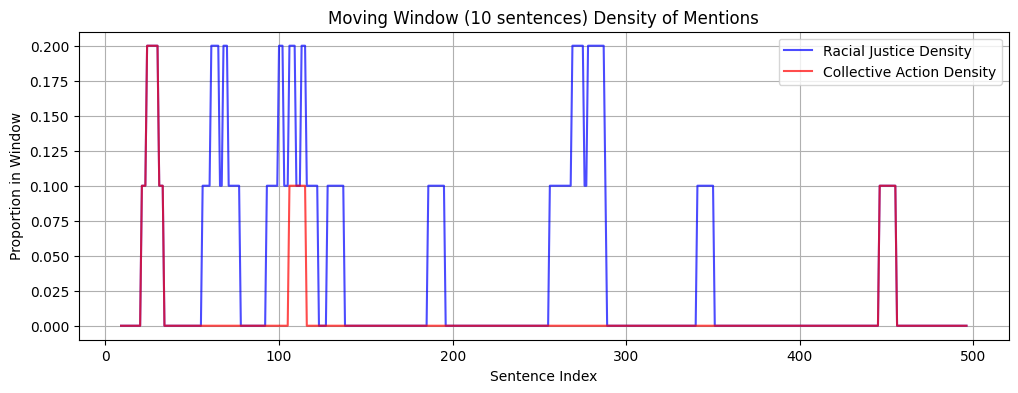

In [274]:
window_size = 10  # Number of sentences to smooth over

# Define racialJustice and collectiveAction conditions
racial_justice = episode_1_data['racialJustice'] == 1
collective_action = (episode_1_data['racialJustice'] == 1) & (episode_1_data['collectiveAction'] == 0)

# Calculate rolling mean for racial justice and collective action based on the conditions
rolling_rj = racial_justice.rolling(window=window_size).mean()
rolling_ca = collective_action.rolling(window=window_size).mean()

# Plot the results
plt.figure(figsize=(12, 4))
plt.plot(rolling_rj, label='Racial Justice Density', color='blue', alpha=0.7)
plt.plot(rolling_ca, label='Collective Action Density', color='red', alpha=0.7)
plt.xlabel('Sentence Index')
plt.ylabel('Proportion in Window')
plt.title(f'Moving Window ({window_size} sentences) Density of Mentions')
plt.legend()
plt.grid(True)
plt.show()

Doing the same for a lot of episodes to get a sense of how much racial justice/collective action discussions there are.

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Define window size for rolling mean
# window_size = 5  # Number of sentences to smooth over

# # Loop through all CSV files in filtered_files
# for file_path in filtered_files:
#     # Load the CSV file into a DataFrame
#     episode_data = pd.read_csv(file_path)
    
#     # Define racialJustice and collectiveAction conditions
#     racial_justice = episode_data['racialJustice'] == 1
#     collective_action = (episode_data['racialJustice'] == 1) & (episode_data['collectiveAction'] == 0)
    
#     # Calculate rolling mean for racial justice and collective action based on the conditions
#     rolling_rj = racial_justice.rolling(window=window_size).mean()
#     rolling_ca = collective_action.rolling(window=window_size).mean()
    
#     # Plot the results
#     plt.figure(figsize=(12, 4))
#     plt.plot(rolling_rj, label='Racial Justice Density', color='blue', alpha=0.7)
#     plt.plot(rolling_ca, label='Collective Action Density', color='red', alpha=0.7)
#     plt.xlabel('Sentence Index')
#     plt.ylabel('Proportion in Window')
#     plt.title(f'Moving Window ({window_size} sentences) Density of Mentions for {file_path}')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

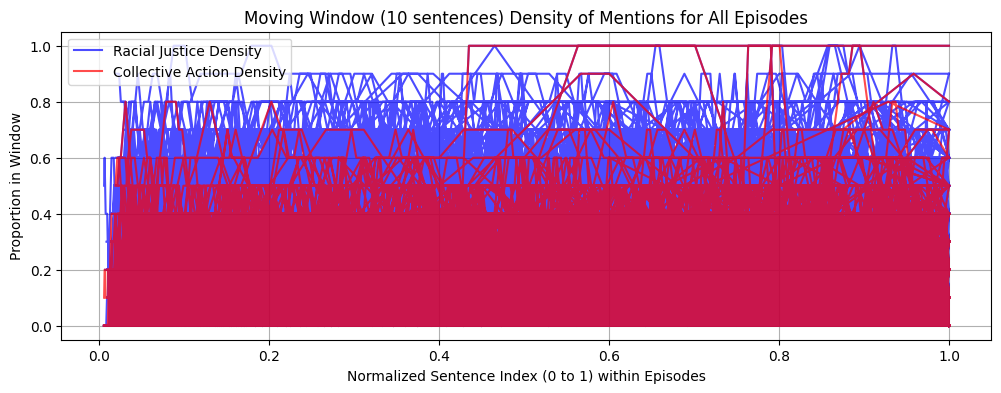

In [151]:
import pandas as pd
import matplotlib.pyplot as plt

# Define window size for rolling mean
window_size = 10  # Number of sentences to smooth over

# Initialize empty lists to store results from all episodes
all_rolling_rj = []
all_rolling_ca = []
all_normalized_x = []  # To store the normalized x-axis values for each episode

# Loop through all CSV files in filtered_files
for file_path in filtered_files:
    # Load the CSV file into a DataFrame
    episode_data = pd.read_csv(file_path)
    
    # Get the number of sentences in the current episode
    num_sentences = len(episode_data)
    
    # Normalize the sentence indices for this episode (0 to 1 range)
    normalized_x = [i / (num_sentences - 1) if num_sentences > 1 else 0 for i in range(num_sentences)]
    
    # Define racialJustice and collectiveAction conditions
    racial_justice = episode_data['racialJustice'] == 1
    collective_action = (episode_data['racialJustice'] == 1) & (episode_data['collectiveAction'] == 0)
    
    # Calculate rolling mean for racial justice and collective action based on the conditions
    rolling_rj = racial_justice.rolling(window=window_size).mean()
    rolling_ca = collective_action.rolling(window=window_size).mean()
    
    # Append the rolling means and normalized x values for this episode
    all_rolling_rj.append(rolling_rj)
    all_rolling_ca.append(rolling_ca)
    all_normalized_x.append(normalized_x)

# Concatenate all results into single series
all_rolling_rj = pd.concat(all_rolling_rj, ignore_index=True)
all_rolling_ca = pd.concat(all_rolling_ca, ignore_index=True)

# Concatenate all normalized x values into a single list
normalized_x_values = [x for episode_x in all_normalized_x for x in episode_x]

# Plot the results for all episodes with normalized x-axis
plt.figure(figsize=(12, 4))
plt.plot(normalized_x_values, all_rolling_rj, label='Racial Justice Density', color='blue', alpha=0.7)
plt.plot(normalized_x_values, all_rolling_ca, label='Collective Action Density', color='red', alpha=0.7)
plt.xlabel('Normalized Sentence Index (0 to 1) within Episodes')
plt.ylabel('Proportion in Window')
plt.title(f'Moving Window ({window_size} sentences) Density of Mentions for All Episodes')
plt.legend()
plt.grid(True)
plt.show()

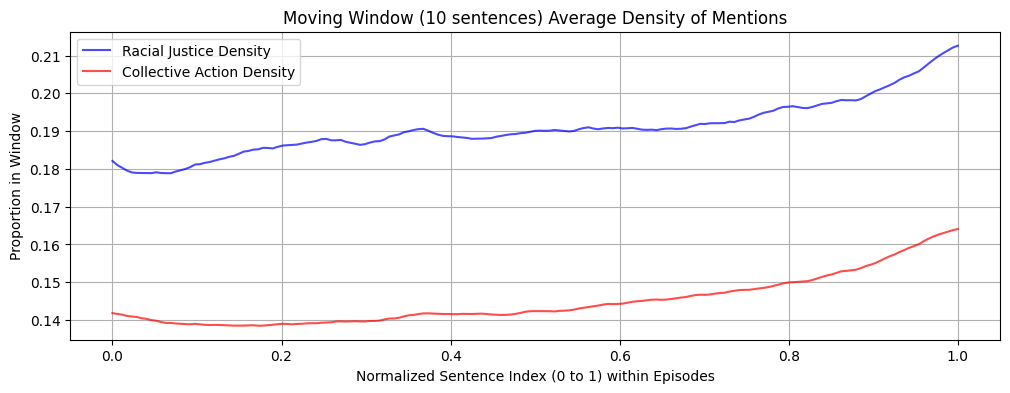

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define window size for rolling mean
window_size = 10 # Number of sentences to smooth over
median_num_sentnces = int(np.median([len(pd.read_csv(file)) for file in filtered_files]))
num_points = median_num_sentences  s

# Initialize lists to store interpolated values
all_interp_rj = []
all_interp_ca = []

# Loop through all CSV files in filtered_files
for file_path in filtered_files_extra:
    # Load the CSV file into a DataFrame
    episode_data = pd.read_csv(file_path)
    
    # Get the number of sentences in the current episode
    num_sentences = len(episode_data)
    
    if num_sentences < window_size:
        continue  # Skip episodes that are too short for rolling mean
    
    # Normalize the sentence indices for this episode (0 to 1 range)
    normalized_x = np.linspace(0, 1, num_sentences)
    
    # Define racialJustice and collectiveAction conditions
    racial_justice = episode_data['racialJustice'] == 1
    collective_action = (episode_data['racialJustice'] == 1) & (episode_data['collectiveAction'] == 0)
    
    # Compute rolling mean but only for sentences where racialJustice or collectiveAction is mentioned
    rolling_rj = racial_justice.rolling(window=window_size, min_periods=1).mean()
    rolling_ca = collective_action.rolling(window=window_size, min_periods=1).mean()
    
    # Mask values where there is no racialJustice or collectiveAction sentence at that point
    rolling_rj[~racial_justice] = np.nan
    rolling_ca[~collective_action] = np.nan
    
    # Interpolate rolling means to a fixed number of points (ignoring NaNs)
    interp_x = np.linspace(0, 1, num_points)
    interp_rj = np.interp(interp_x, normalized_x[~rolling_rj.isna()], rolling_rj.dropna()) if not rolling_rj.dropna().empty else np.zeros(num_points)
    interp_ca = np.interp(interp_x, normalized_x[~rolling_ca.isna()], rolling_ca.dropna()) if not rolling_ca.dropna().empty else np.zeros(num_points)
    
    # Store interpolated values
    all_interp_rj.append(interp_rj)
    all_interp_ca.append(interp_ca)

# Compute the average across all episodes
mean_rj = np.nanmean(all_interp_rj, axis=0)
mean_ca = np.nanmean(all_interp_ca, axis=0)

# Plot the averaged density lines
plt.figure(figsize=(12, 4))
plt.plot(np.linspace(0, 1, num_points), mean_rj, label='Racial Justice Density', color='blue', alpha=0.7)
plt.plot(np.linspace(0, 1, num_points), mean_ca, label='Collective Action Density', color='red', alpha=0.7)
plt.xlabel('Normalized Sentence Index (0 to 1) within Episodes')
plt.ylabel('Proportion in Window')
plt.title(f'Moving Window ({window_size} sentences) Average Density of Mentions')
plt.legend()
plt.grid(True)
plt.show()


### All episodes with racial justice discussions

First we remove the religion episodes.

In [163]:
episodes_data = pd.read_csv("../data/episodes_with_id.csv")
unique_categories = episodes_data['category1'].unique()
print(unique_categories)

['society' 'education' 'religion' 'news' 'tv' 'business' 'comedy' 'health'
 'sports' 'arts' 'leisure' 'technology' 'government' 'music' 'science'
 'history' 'kids' 'games' 'fiction' nan 'true crime' 'politics' 'places'
 'christianity']


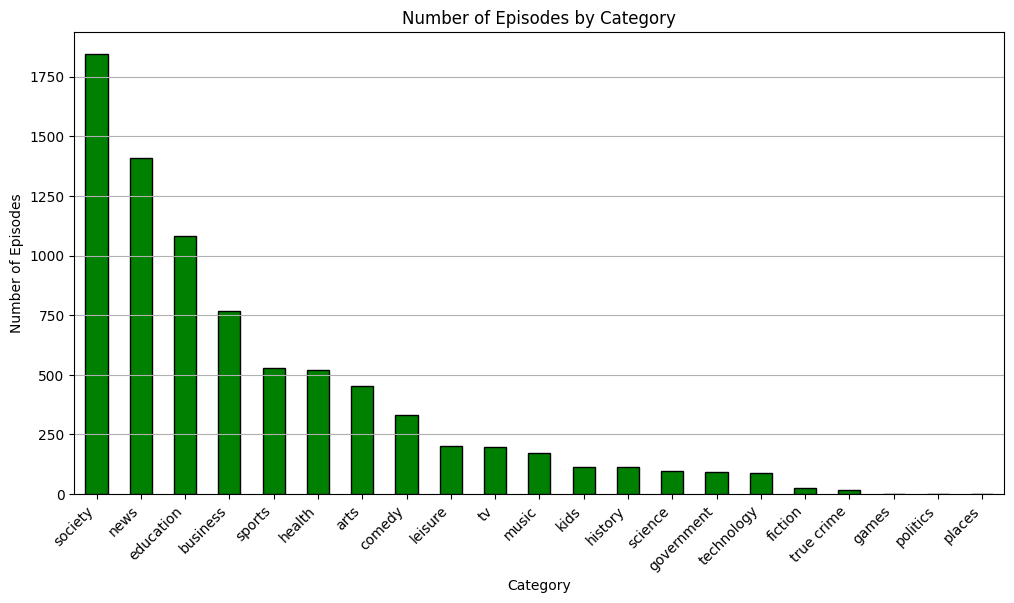

In [232]:
# Filter out rows where category1 is 'religion' or 'christianity'
filtered_episodes = episodes_data[~episodes_data['category1'].isin(['religion', 'christianity'])]

# Count the number of episodes for each category
category_counts = filtered_episodes['category1'].value_counts()

# Plot the results
plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar', color='green', edgecolor='black')
plt.xlabel('Category')
plt.ylabel('Number of Episodes')
plt.title('Number of Episodes by Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

In [187]:
# Extract the base URL before the third '/'
filtered_episodes['base_rssUrl'] = filtered_episodes['rssUrl'].apply(lambda x: '/'.join(x.split('/')[:3]))

# Count the number of episodes for each base URL
base_url_counts = filtered_episodes['base_rssUrl'].value_counts()

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_87000/1540370799.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_episodes['base_rssUrl'] = filtered_episodes['rssUrl'].apply(lambda x: '/'.join(x.split('/')[:3]))


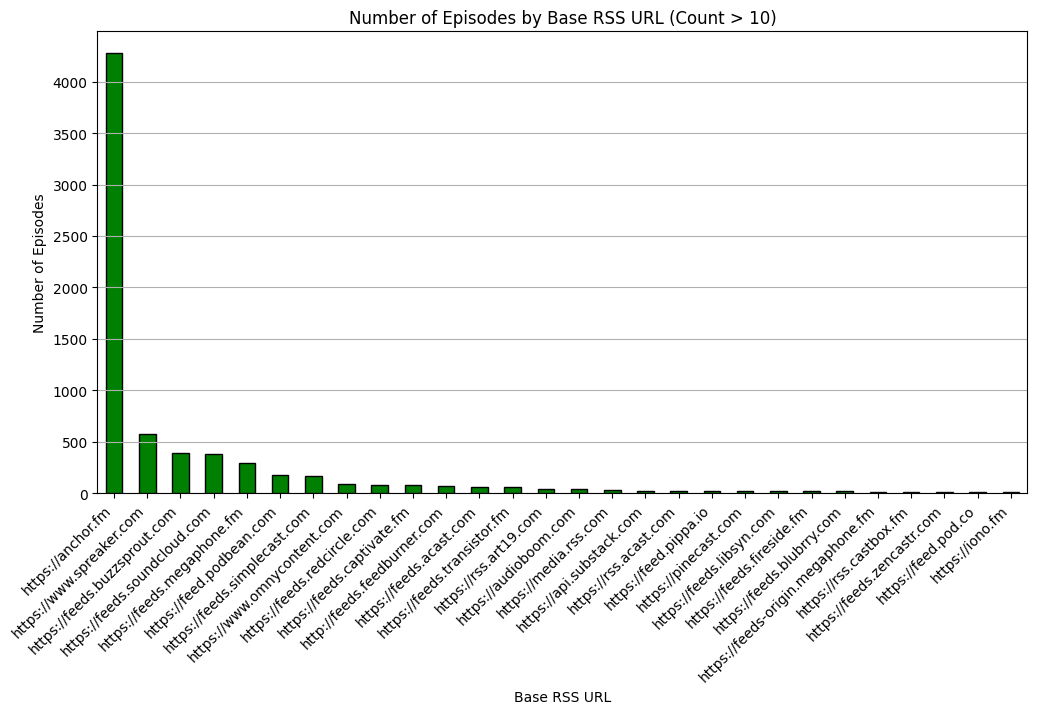

In [192]:
# Filter base URLs with a count above 10
filtered_base_url_counts = base_url_counts[base_url_counts > 10]

# Plot the results
plt.figure(figsize=(12, 6))
filtered_base_url_counts.plot(kind='bar', color='green', edgecolor='black')
plt.xlabel('Base RSS URL')
plt.ylabel('Number of Episodes')
plt.title('Number of Episodes by Base RSS URL (Count > 10)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

In [195]:
explicit_counts = filtered_episodes['explicit'].value_counts()
print(explicit_counts)

explicit
0    6253
1    1874
Name: count, dtype: int64


In [198]:
# Initialize lists to store proportions
explicit_proportions = []
non_explicit_proportions = []

# Loop through all CSV files in filtered_files
for file_path in filtered_files:
    # Load the CSV file into a DataFrame
    episode_data = pd.read_csv(file_path)
    
    # Get the explicit value for the current episode
    episode_id_str = os.path.basename(file_path).replace("episode_", "").replace(".csv", "")
    episode_id = int(episode_id_str)
    explicit_value = episodes_data[episodes_data['episode_id'] == episode_id]['explicit'].values[0]
    
    # Calculate the proportion of collective action sentences
    total_sentences = len(episode_data)
    collective_action_sentences = len(episode_data[(episode_data['collectiveAction'] == 0) & (episode_data['racialJustice'] == 1)])
    proportion = collective_action_sentences / total_sentences if total_sentences > 0 else 0
    
    # Append the proportion to the appropriate list
    if explicit_value == 1:
        explicit_proportions.append(proportion)
    else:
        non_explicit_proportions.append(proportion)

# Calculate the average proportion for explicit and non-explicit episodes
avg_explicit_proportion = sum(explicit_proportions) / len(explicit_proportions) if explicit_proportions else 0
avg_non_explicit_proportion = sum(non_explicit_proportions) / len(non_explicit_proportions) if non_explicit_proportions else 0

# Print the results
print(f'Average proportion of collective action sentences in explicit episodes: {avg_explicit_proportion:.4f}')
print(f'Average proportion of collective action sentences in non-explicit episodes: {avg_non_explicit_proportion:.4f}')

Average proportion of collective action sentences in explicit episodes: 0.0376
Average proportion of collective action sentences in non-explicit episodes: 0.0348


In [ ]:
# # Initialize a counter for episodes with the column 'collectiveActionMulti'
# count_collective_action_multi = 0

# # Loop through all CSV files in filtered_files
# for file_path in filtered_files:
#     # Load the CSV file into a DataFrame
#     episode_data = pd.read_csv(file_path)
    
#     # Check if the column 'collectiveActionMulti' exists in the DataFrame
#     if 'collectiveActionMulti' in episode_data.columns:
#         count_collective_action_multi += 1

# # Print the count
# print(f'Number of episodes with the column "collectiveActionMulti": {count_collective_action_multi}')

Number of episodes with the column "collectiveActionMulti": 7523


In [218]:
filtered_files_extra = []

# Loop through all CSV files in filtered_files
for file_path in filtered_files:
    # Load the CSV file into a DataFrame
    episode_data = pd.read_csv(file_path)
    
    # Check if there is at least one row where collectiveAction = 0 and racialJustice = 1
    if not episode_data[(episode_data['collectiveAction'] == 0) & (episode_data['racialJustice'] == 1)].empty:
        filtered_files_extra.append(file_path)

len(filtered_files_extra)

6366

In [220]:
total_rows = 0

# Loop through all CSV files in filtered_files
for file_path in filtered_files_extra:
    # Load the CSV file into a DataFrame
    episode_data = pd.read_csv(file_path)
    
    # Count the number of rows where collectiveAction is 0 and racialJustice is 1
    count = len(episode_data[(episode_data['collectiveAction'] == 0) & (episode_data['racialJustice'] == 1)])
    
    # Add the count to the total
    total_rows += count

# Print the total number of rows
print(f'Total number of rows with collectiveAction = 0 and racialJustice = 1: {total_rows}')

Total number of rows with collectiveAction = 0 and racialJustice = 1: 39326


In [221]:
# Initialize counters for each value of collectiveActionMulti
count_0 = 0
count_1 = 0
count_2 = 0
count_3 = 0

# Loop through all CSV files in filtered_files
for file_path in filtered_files_extra:
    # Load the CSV file into a DataFrame
    episode_data = pd.read_csv(file_path)
    
    # Filter rows where collectiveAction = 0 and racialJustice = 1
    filtered_data = episode_data[(episode_data['collectiveAction'] == 0) & (episode_data['racialJustice'] == 1)]
    
    # Check if the column 'collectiveActionMulti' exists in the DataFrame
    if 'collectiveActionMulti' in filtered_data.columns:
        # Count the occurrences of each value in the 'collectiveActionMulti' column
        count_0 += (filtered_data['collectiveActionMulti'] == 0).sum()
        count_1 += (filtered_data['collectiveActionMulti'] == 1).sum()
        count_2 += (filtered_data['collectiveActionMulti'] == 2).sum()
        count_3 += (filtered_data['collectiveActionMulti'] == 3).sum()

# Print the total counts
print(f'Total count of collectiveActionMulti = 0: {count_0}')
print(f'Total count of collectiveActionMulti = 1: {count_1}')
print(f'Total count of collectiveActionMulti = 2: {count_2}')
print(f'Total count of collectiveActionMulti = 3: {count_3}')

Total count of collectiveActionMulti = 0: 25326
Total count of collectiveActionMulti = 1: 4187
Total count of collectiveActionMulti = 2: 4858
Total count of collectiveActionMulti = 3: 4955


In [213]:
# Count the number of each unique category in the column 'podTitle'
pod_title_counts = filtered_episodes['podTitle'].value_counts()

# Rank them from high to low
pod_title_counts_sorted = pod_title_counts.sort_values(ascending=False)

# Display the result
print(pod_title_counts_sorted)

podTitle
Bill O’Reilly’s No Spin News and Analysis    27
JVC Broadcasting                             14
Conservative Review with Daniel Horowitz     12
Liberation Audio                             11
TalkJive.org                                  9
                                             ..
sanamkhanlou                                  1
the.4th.supernova                             1
The Music Reviewer                            1
VIEW/Z                                        1
Everything Is Everything                      1
Name: count, Length: 6711, dtype: int64


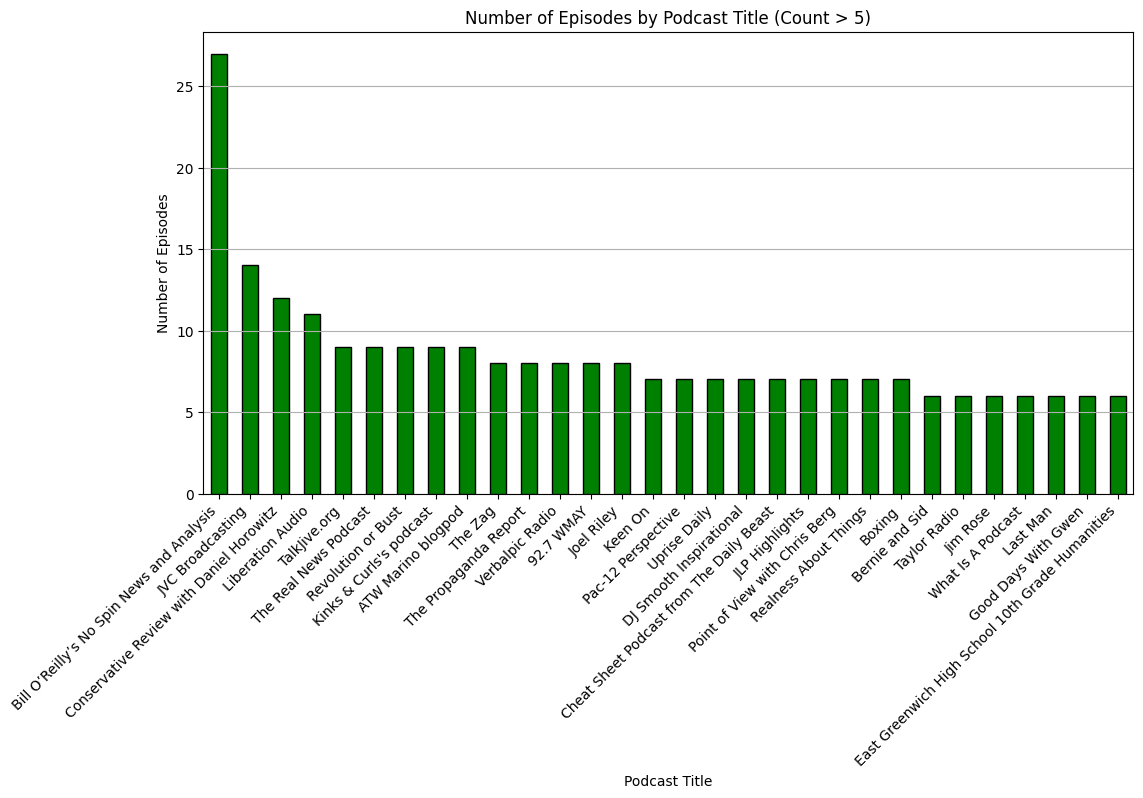

In [217]:
# Filter pod titles with count greater than 1
filtered_pod_title_counts = pod_title_counts_sorted[pod_title_counts_sorted > 5]

# Plot the results
plt.figure(figsize=(12, 6))
filtered_pod_title_counts.plot(kind='bar', color='green', edgecolor='black')
plt.xlabel('Podcast Title')
plt.ylabel('Number of Episodes')
plt.title('Number of Episodes by Podcast Title (Count > 5)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

In [ ]:
numMainSpeakers.columns

Index(['transcript', 'rssUrl', 'epTitle', 'epDescription', 'mp3url',
       'podTitle', 'lastUpdate', 'itunesAuthor', 'itunesOwnerName', 'explicit',
       'imageUrl', 'language', 'createdOn', 'host', 'podDescription',
       'category1', 'category2', 'category3', 'category4', 'category5',
       'category6', 'category7', 'category8', 'category9', 'category10',
       'oldestEpisodeDate', 'episodeDateLocalized', 'durationSeconds',
       'hostPredictedNames', 'numUniqueHosts', 'guestPredictedNames',
       'numUniqueGuests', 'neitherPredictedNames', 'numUniqueNeithers',
       'mainEpSpeakers', 'numMainSpeakers', 'hostSpeakerLabels',
       'guestSpeakerLabels', 'overlapPropTurnCount', 'avgTurnDuration',
       'overlapPropDuration', 'totalSpLabels', 'tokens', 'BLM',
       'tokens_transcript', 'sentences', 'diarized', 'badDiarization',
       'episode_id', 'base_rssUrl'],
      dtype='object')

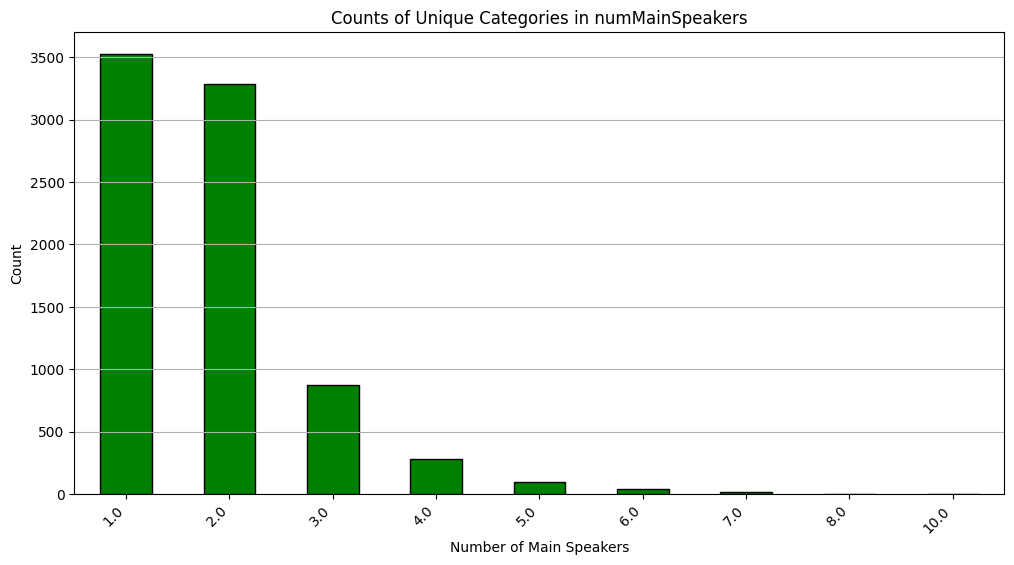

In [229]:
# Count the number of unique categories in numMainSpeakers
num_main_speakers_counts = filtered_episodes['numMainSpeakers'].value_counts()

# Plot the results
plt.figure(figsize=(12, 6))
num_main_speakers_counts.plot(kind='bar', color='green', edgecolor='black')
plt.xlabel('Number of Main Speakers')
plt.ylabel('Count')
plt.title('Counts of Unique Categories in numMainSpeakers')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

In [238]:
# Count the number of unique categories in numMainSpeakers
num_main_speakers_counts = filtered_episodes['numMainSpeakers'].value_counts()
num_main_speakers_counts

numMainSpeakers
1.0     3524
2.0     3281
3.0      875
4.0      284
5.0       98
6.0       44
7.0       18
8.0        2
10.0       1
Name: count, dtype: int64

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_87000/2733717181.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_episodes_2hours['durationSeconds'] = filtered_episodes_2hours['durationSeconds'].clip(upper=7200)


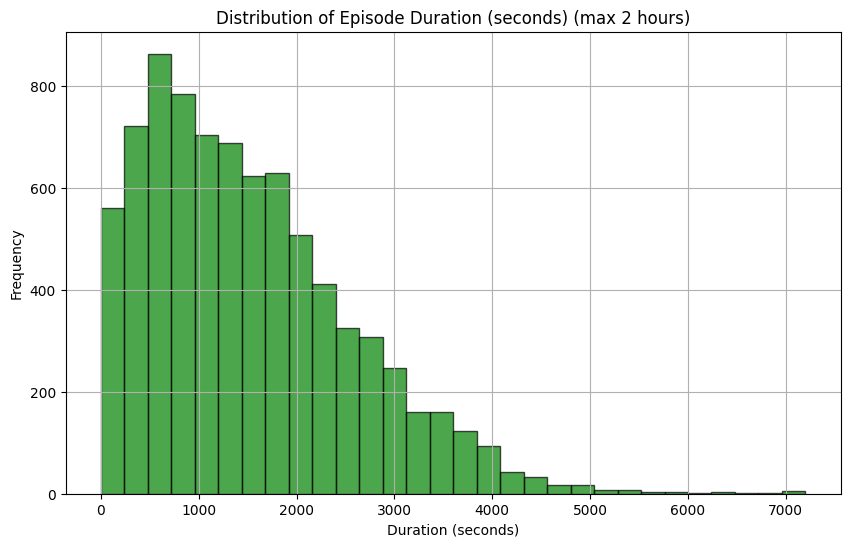

In [234]:
# Cap the distribution of durationSeconds at 2 hours 
filtered_episodes_2hours = filtered_episodes
filtered_episodes_2hours['durationSeconds'] = filtered_episodes_2hours['durationSeconds'].clip(upper=7200)

# Plot the distribution of durationSeconds for filtered_episodes
plt.figure(figsize=(10, 6))
plt.hist(filtered_episodes_2hours['durationSeconds'].dropna(), bins=30, color='green', alpha=0.7, edgecolor='black')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Episode Duration (seconds) (max 2 hours)')
plt.grid(True)
plt.show()

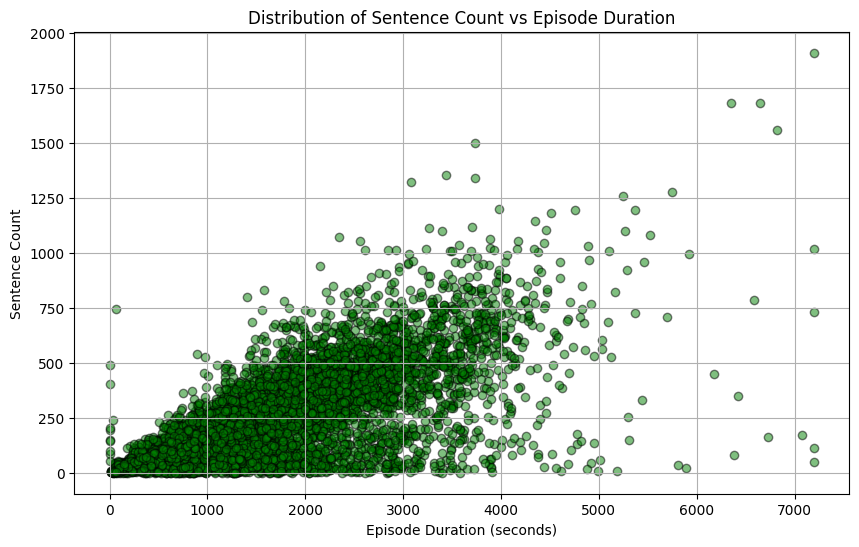

In [236]:
# Extract sentence count and episode duration for all episodes
sentence_counts = filtered_episodes_2hours['sentences']
episode_durations = filtered_episodes_2hours['durationSeconds']

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.scatter(episode_durations, sentence_counts, alpha=0.5, color='green', edgecolor='black')
plt.xlabel('Episode Duration (seconds)')
plt.ylabel('Sentence Count')
plt.title('Distribution of Sentence Count vs Episode Duration')
plt.grid(True)
plt.show()

In [173]:
# Filter rows where category1 is religion or christianity
religion_episodes = episodes_data[episodes_data['category1'].isin(['religion', 'christianity'])]
religion_episode_ids = religion_episodes['episode_id'].unique()
religion_episode_ids

array([    3,     9,    10, ..., 10478, 10479, 10493])

In [174]:
filtered_files = []
for i in range(1, 11):
    files = glob.glob(f"../data/episodes/part_{i}/*.csv")
    for file in files:
        episode_id_str = os.path.basename(file).replace("episode_", "").replace(".csv", "")
        try:
            episode_id = int(episode_id_str)  # Convert to integer
        except ValueError:
            print(f"Skipping file {file} due to invalid episode_id: {episode_id_str}")
            continue
        
        if episode_id not in religion_episode_ids:
            filtered_files.append(file)

file_lengths = [len(pd.read_csv(file)) for file in filtered_files]

In [175]:
len(filtered_files)

8127

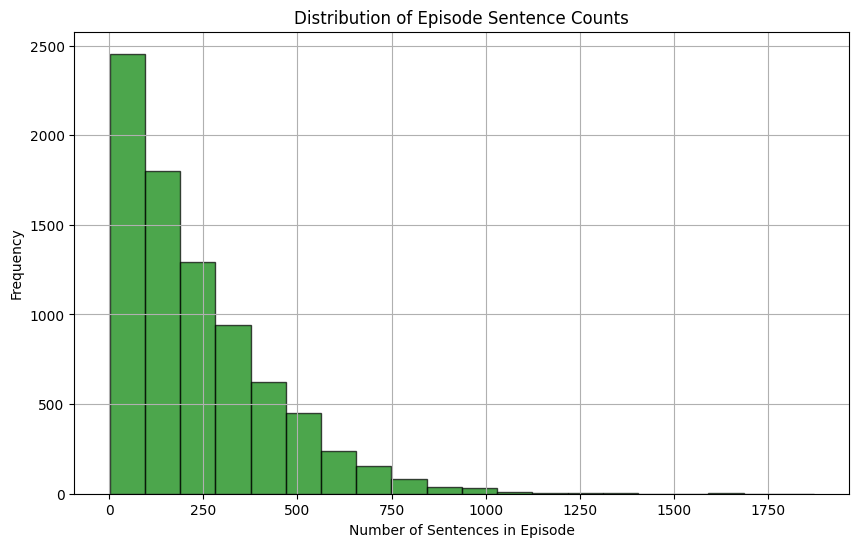

In [176]:
# Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(file_lengths, bins=20, color='green', alpha=0.7, edgecolor='black')
plt.xlabel('Number of Sentences in Episode')
plt.ylabel('Frequency')
plt.title('Distribution of Episode Sentence Counts')
plt.grid(True)
plt.show()

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_87000/1824911566.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_episodes_data['epDescription'] = filtered_episodes_data['epDescription'].fillna('')
/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_87000/1824911566.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_episodes_data['epDescription'] = filtered_episodes_data['epDescription'].apply(remove_urls)


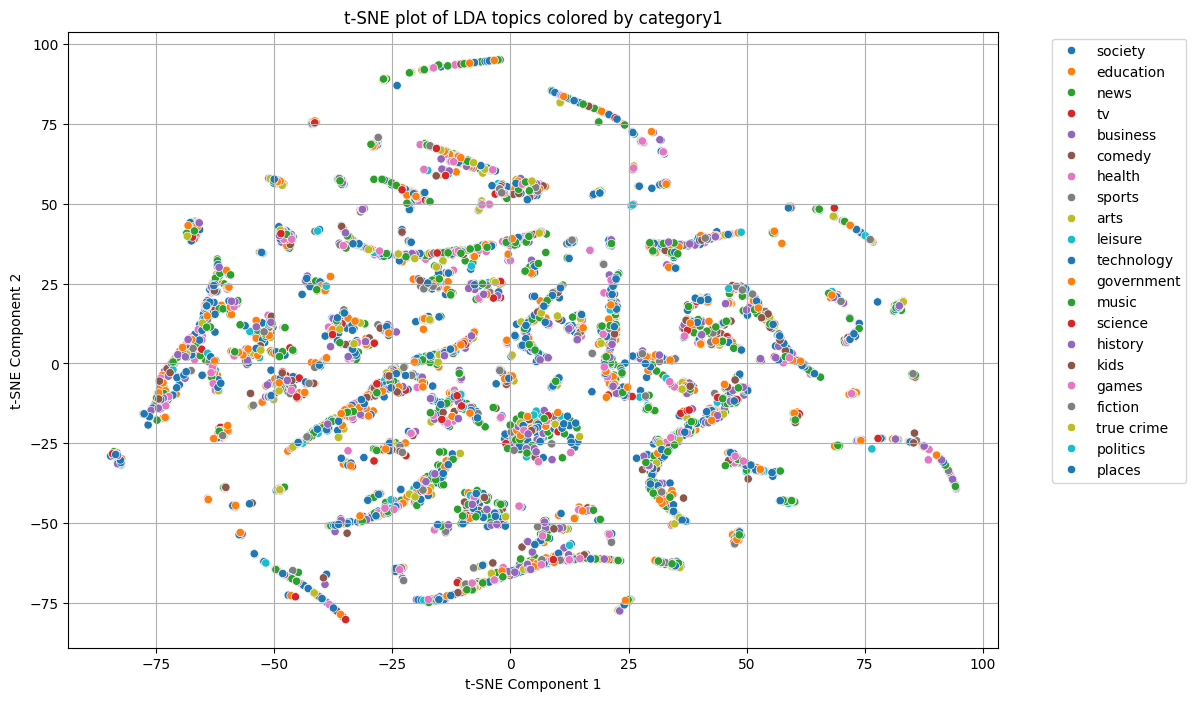

In [253]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.manifold import TSNE
import seaborn as sns

import matplotlib.pyplot as plt

# Preprocess the text data
filtered_episodes_data['epDescription'] = filtered_episodes_data['epDescription'].fillna('')

# from bs4 import BeautifulSoup

# def clean_html(text):
#     return BeautifulSoup(text, "html.parser").get_text()

# filtered_episodes_data['epDescription'] = filtered_episodes_data['epDescription'].apply(clean_html)

# import re

def remove_urls(text):
    return re.sub(r'http[s]?://\S+', '', text)

filtered_episodes_data['epDescription'] = filtered_episodes_data['epDescription'].apply(remove_urls)

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = set(ENGLISH_STOP_WORDS).union({'https', 'com', 'www', 'href', 'org', 'amp', 'episode', 'podcast', 'support', 'message', 'spotify', 'pod', 'class', 'br', 'li', 'strong', 'style', 'data', 'instagram', 'twitter', 'facebook', 'youtube', 'http', 'nofollow', 'noreferrer', 'noopener', 'color', 'font', 'size', 'span', 'ugс', 'rel', 'target'})

vectorizer = CountVectorizer(stop_words=list(custom_stopwords), max_features=1000)
X = vectorizer.fit_transform(filtered_episodes_data['epDescription'])

# Perform LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda_topics = lda.fit_transform(X)

# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(lda_topics)

# Create a DataFrame with t-SNE results and category1
tsne_df = pd.DataFrame(tsne_results, columns=['tsne1', 'tsne2'])
tsne_df['category1'] = filtered_episodes_data['category1']

# Plot the t-SNE results
plt.figure(figsize=(12, 8))
sns.scatterplot(x='tsne1', y='tsne2', hue='category1', data=tsne_df, palette='tab10', legend='full')
plt.title('t-SNE plot of LDA topics colored by category1')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [254]:
# Get the feature names (words) from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Get the top 20 words for each topic
top_n = 20
top_words = {}

for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-top_n:][::-1]
    top_words[topic_idx] = [feature_names[i] for i in top_indices]

# Print the top words for each topic
for topic_idx, words in top_words.items():
    print(f"Topic {topic_idx}: {', '.join(words)}")

Topic 0: black, racism, lives, matter, white, floyd, george, police, people, movement, justice, racial, community, race, anti, change, protests, america, resources, racist
Topic 1: week, follow, talk, new, subscribe, discuss, music, today, news, podcasts, listen, check, gmail, review, patreon, 2020, share, episodes, content, special
Topic 2: covid, 19, privacy, new, visit, dr, information, learn, university, ad, acast, choices, american, pandemic, health, state, president, 2020, adchoices, discuss
Topic 3: life, work, voice, world, business, send, people, today, health, community, social, help, women, free, learn, make, share, talk, change, time
Topic 4: like, just, people, know, time, going, don, right, things, ve, really, think, 00, want, way, say, love, life, world, need


In [258]:
import pandas as pd

# Get the dominant topic for each row
dominant_topics = lda_topics.argmax(axis=1)

# Filter rows where Topic 0 is the most dominant
topic_0_rows = filtered_episodes_data[dominant_topics == 0]

# Display all rows in topic 0
topic_0_rows

,transcript,rssUrl,epTitle,epDescription,mp3url,podTitle,lastUpdate,itunesAuthor,itunesOwnerName,explicit,...,avgTurnDuration,overlapPropDuration,totalSpLabels,tokens,BLM,tokens_transcript,sentences,diarized,badDiarization,episode_id
4,"On May 25th, 2020, George Perry Floyd died at...",https://anchor.fm/s/126c0978/podcast/rss,George Floyd,"Moderator Brodie Myers, with panelist Micah Wi...",https://anchor.fm/s/126c0978/podcast/play/1460...,One Whole Revolution,2021-06-03 19:56:26,Brodie Myers,Brodie Myers,0,...,53.702400,0.002540,2.0,moderator brodie myers panelist micah wilcox d...,0,may george perry floyd died hands former minne...,154,1,0.0,5
7,[MUSIC PLAYING] Welcome to today's episode of...,https://anchor.fm/s/a95405c/podcast/rss,The Truth About Black History,This week @stevecanal & @ajjoiner review: Defi...,https://anchor.fm/s/a95405c/podcast/play/13625...,What's in the Words,2021-06-17 10:33:51,"AJ Joiner, Steve Canal","AJ Joiner, Steve Canal",1,...,13.098750,0.024048,2.0,week stevecanal amp ajjoiner review defining m...,0,music playing welcome todays episode whats wor...,119,1,0.0,8
13,"This is Fresh Shed, a weekly podcast that mak...",https://feeds.soundcloud.com/users/soundcloud:...,FreshEd #201 – Racism and Police Violence in A...,The murder of George Floyd has ignited a globa...,http://www.podtrac.com/pts/redirect.mp3/feeds....,FreshEd,2023-10-16 01:54:44,FreshEd with Will Brehm,The FreshEd Podcast,0,...,31.855484,0.005782,2.0,murder george floyd ignited global outcry raci...,0,fresh shed weekly podcast makes complex ideas ...,321,1,0.0,14
14,Protests over the murder of George Floyd have...,https://feeds.soundcloud.com/users/soundcloud:...,FreshEd #175 – Violence Interrupters In Chicag...,Protests over the murder of George Floyd have ...,http://www.podtrac.com/pts/redirect.mp3/feeds....,FreshEd,2023-10-16 01:54:44,FreshEd with Will Brehm,The FreshEd Podcast,0,...,12.898545,0.021407,2.0,protests murder george floyd erupted across un...,0,protests murder george floyd erupted across un...,436,1,0.0,15
18,What's up everyone? It's just a quiet one com...,https://anchor.fm/s/29c08cc/podcast/rss,#BlackLivesMatter,R.I.P to all black lives that were taken from ...,https://anchor.fm/s/29c08cc/podcast/play/14569...,Jazz The Quiet One,2021-07-12 19:56:49,Jazz The Quiet One,Jazz The Quiet One,0,...,379.000000,0.000000,1.0,rip black lives taken world due people overusi...,0,whats everyone quiet one coming back tonight a...,67,1,0.0,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10473,"Hello and welcome to Over the Pondcast, I'm E...",https://anchor.fm/s/1fce2768/podcast/rss,Episode 5 - Stand up for change,In this weeks episode we speak about the riots...,https://anchor.fm/s/1fce2768/podcast/play/1478...,Over the Pondcast,2021-06-08 00:23:34,Andrew Ritchie,Andrew Ritchie,0,...,10.766053,0.038246,2.0,weeks episode speak riots protests america alo...,0,hello welcome pondcast edan gobright andrew ri...,67,1,0.0,10474
10475,[MUSIC] Welcome to the social millennial podc...,https://marcuspenapresents.libsyn.com/rss,RIP Mr. Floyd,,https://traffic.libsyn.com/secure/marcuspenapr...,The Social Millenial Podcast,2022-09-24 05:30:43,Marcus Peña,Marcus Peña,0,...,2541.120000,0.000000,1.0,NaN,0,music welcome social millennial podcast much g...,132,1,0.0,10476
10479,[MUSIC PLAYING] [MUSIC PLAYING] [MUSIC PLAYIN...,https://anchor.fm/s/f6df574/podcast/rss,Mysterious Deaths of Black Men found hanged o...,Thank you guys for tuning in. This episode was...,https://anchor.fm/s/f6df574/podcast/play/15748...,Curious Conscious,2022-05-12 08:38:13,Nikea Banks,Nikea Banks,0,...,825.620000,0.000000,1.0,strongthank guys tuning episode created bring ...,0,music playing music playing music playing musi...,139,1,0.0,10480
10488,Hello everybody and welcome to the bonus epis...,https://anchor.fm/s/1fc72864/podcast/rss,Bonus,,https://anchor.fm/s/1fc72864/podcast/play/1466...,Breaking Down The Tape,2023-09-23 01:29:33,Zach

In [262]:
topic_0_rows.to_csv('../data/blm_episodes.csv', index=False)

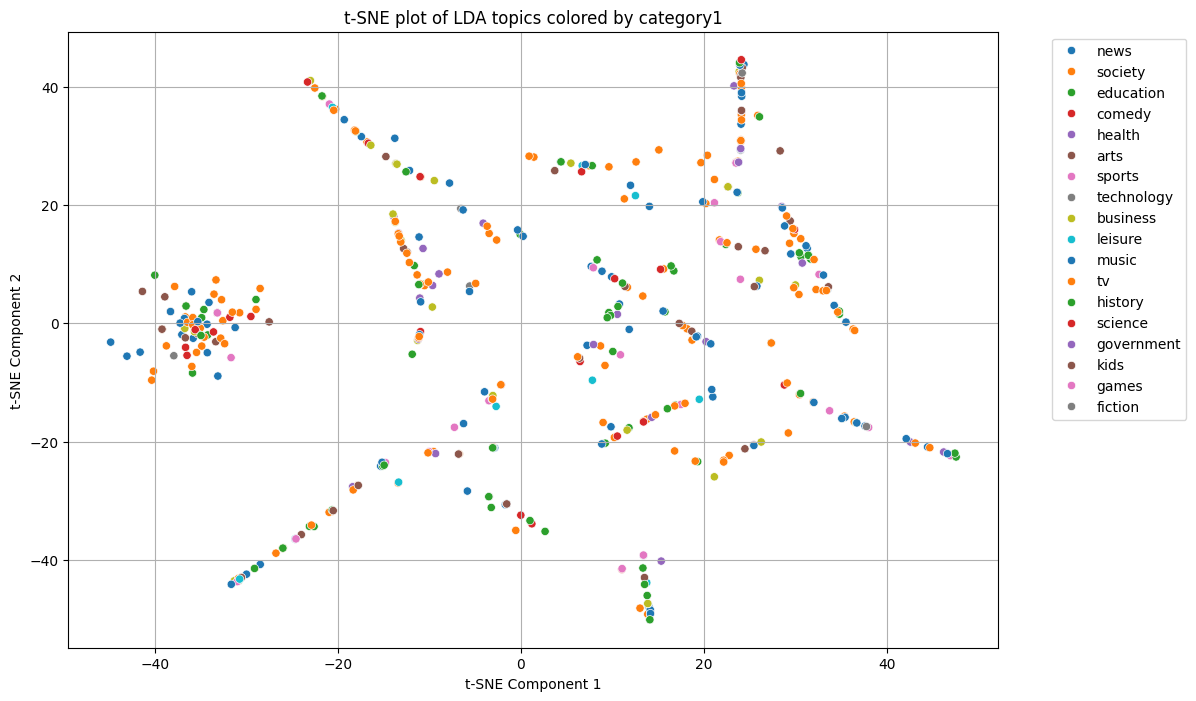

In [264]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.manifold import TSNE
import seaborn as sns

import matplotlib.pyplot as plt

filtered_episodes_data = topic_0_rows

# Preprocess the text data
filtered_episodes_data['epDescription'] = filtered_episodes_data['epDescription'].fillna('')

# from bs4 import BeautifulSoup

# def clean_html(text):
#     return BeautifulSoup(text, "html.parser").get_text()

# filtered_episodes_data['epDescription'] = filtered_episodes_data['epDescription'].apply(clean_html)

# import re

def remove_urls(text):
    return re.sub(r'http[s]?://\S+', '', text)

filtered_episodes_data['epDescription'] = filtered_episodes_data['epDescription'].apply(remove_urls)

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = set(ENGLISH_STOP_WORDS).union({'https', 'com', 'www', 'href', 'org', 'amp', 'episode', 'podcast', 'support', 'message', 'spotify', 'pod', 'class', 'br', 'li', 'strong', 'style', 'data', 'instagram', 'twitter', 'facebook', 'youtube', 'http', 'nofollow', 'noreferrer', 'noopener', 'color', 'font', 'size', 'span', 'ugс', 'rel', 'target'})

vectorizer = CountVectorizer(stop_words=list(custom_stopwords), max_features=1000)
X = vectorizer.fit_transform(filtered_episodes_data['epDescription'])

# Perform LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda_topics = lda.fit_transform(X)

# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(lda_topics)

# Create a DataFrame with t-SNE results and category1
tsne_df = pd.DataFrame(tsne_results, columns=['tsne1', 'tsne2'])
tsne_df['category1'] = filtered_episodes_data['category1']

# Plot the t-SNE results
plt.figure(figsize=(12, 8))
sns.scatterplot(x='tsne1', y='tsne2', hue='category1', data=tsne_df, palette='tab10', legend='full')
plt.title('t-SNE plot of LDA topics colored by category1')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [265]:
# Get the feature names (words) from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Get the top 20 words for each topic
top_n = 20
top_words = {}

for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-top_n:][::-1]
    top_words[topic_idx] = [feature_names[i] for i in top_indices]

# Print the top words for each topic
for topic_idx, words in top_words.items():
    print(f"Topic {topic_idx}: {', '.join(words)}")

Topic 0: black, lives, matter, people, movement, donate, week, community, voice, help, send, bail, voices, time, stand, fund, resources, right, listen, make
Topic 1: police, black, lives, floyd, george, people, matter, movement, brutality, protests, today, discuss, violence, murder, 2020, racial, community, racism, protest, justice
Topic 2: black, lives, floyd, george, matter, justice, action, racism, change, sign, fund, police, week, speak, breonna, believe, fm, movement, voices, podcasters
Topic 3: floyd, george, racism, send, voice, america, protests, discuss, death, police, black, country, ahmaud, arbery, taylor, talk, thoughts, change, murder, social
Topic 4: white, racism, people, black, anti, resources, racist, race, talk, racial, supremacy, privilege, work, justice, better, want, book, world, change, books


In [ ]:
# import pandas as pd
# import numpy as np
# import glob
# import os
# import matplotlib.pyplot as plt

# # Function to extract episode ID from file name
# def get_episode_id(filename):
#     return os.path.basename(filename).replace("episode_", "").replace(".csv", "")

# # Process and store episode data
# episodes = []

# for file in filtered_files:
#     episode_id = get_episode_id(file)  # Extract episode ID
#     df = pd.read_csv(file)  # Load CSV
#     df["episodeID"] = episode_id  # Add episode ID
#     df["sentence_index"] = np.linspace(0, 1, len(df))  # Normalize sentence index (0 to 1)
#     df["rolling_avg"] = df["collectiveAction"].rolling(window=10, min_periods=1).mean()  # Compute moving average
#     episodes.append(df)

# # Combine all episodes
# df_all = pd.concat(episodes, ignore_index=True)

# # Plot multiple episode moving averages
# plt.figure(figsize=(12, 6))

# # Plot a subset of episodes to avoid over-plotting (e.g., first 100 episodes)
# # for episode_id, episode in df_all.groupby("episodeID"):
# #     plt.plot(episode["sentence_index"], episode["rolling_avg"], alpha=0.3, lw=1)
# for episode_id, episode in df_all.groupby("episodeID"):
#     plt.plot(episode["sentence_index"], episode["rolling_avg"], alpha=0.3, lw=1, label=f"Episode {episode_id}")

# plt.legend()

# # Optional: Compute and plot the **average trend** across all episodes
# df_mean = df_all.groupby("sentence_index")["rolling_avg"].mean()
# #plt.plot(df_mean.index, df_mean.values, color="red", linewidth=2, label="Average trend")
# #df_all.groupby("sentence_index")["rolling_avg"].mean().plot()

# # Labels and legend
# plt.xlabel("Normalized Sentence Position (0 = Start, 1 = End)")
# plt.ylabel("Moving Average of Collective Action Sentences")
# plt.title("Collective Action Discussion Trends Across Episodes")
# #plt.legend()
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Define window size for rolling mean
# window_size = 5  # Number of sentences to smooth over
# agg_window_size = 100  # Size of the window for aggregation (larger value to smooth over all data)

# # Initialize empty lists to store results from all episodes
# all_rolling_rj = []
# all_rolling_ca = []
# all_normalized_x = []  # To store the normalized x-axis values for each episode

# # Loop through all CSV files in filtered_files
# for file_path in filtered_files:
#     # Load the CSV file into a DataFrame
#     episode_data = pd.read_csv(file_path)
    
#     # Get the number of sentences in the current episode
#     num_sentences = len(episode_data)
    
#     # Normalize the sentence indices for this episode (0 to 1 range)
#     normalized_x = [i / (num_sentences - 1) if num_sentences > 1 else 0 for i in range(num_sentences)]
    
#     # Define racialJustice and collectiveAction conditions
#     racial_justice = episode_data['racialJustice'] == 1
#     collective_action = (episode_data['racialJustice'] == 1) & (episode_data['collectiveAction'] == 0)
    
#     # Calculate rolling mean for racial justice and collective action based on the conditions
#     rolling_rj = racial_justice.rolling(window=window_size).mean()
#     rolling_ca = collective_action.rolling(window=window_size).mean()
    
#     # Append the rolling means and normalized x values for this episode
#     all_rolling_rj.append(rolling_rj)
#     all_rolling_ca.append(rolling_ca)
#     all_normalized_x.append(normalized_x)

# # Concatenate all results into single series
# all_rolling_rj = pd.concat(all_rolling_rj, ignore_index=True)
# all_rolling_ca = pd.concat(all_rolling_ca, ignore_index=True)

# # Concatenate all normalized x values into a single list
# normalized_x_values = [x for episode_x in all_normalized_x for x in episode_x]

# # Aggregation to smooth the plot
# aggregated_rolling_rj = all_rolling_rj.rolling(window=agg_window_size).mean()
# aggregated_rolling_ca = all_rolling_ca.rolling(window=agg_window_size).mean()
# aggregated_normalized_x = [x for x in normalized_x_values if not pd.isnull(all_rolling_rj.iloc[normalized_x_values.index(x)])]

# # Plot the results for all episodes with aggregated (smoothed) x-axis
# plt.figure(figsize=(12, 4))
# plt.plot(aggregated_normalized_x, aggregated_rolling_rj, label='Racial Justice Density', color='blue', alpha=0.7)
# plt.plot(aggregated_normalized_x, aggregated_rolling_ca, label='Collective Action Density', color='red', alpha=0.7)
# plt.xlabel('Normalized Sentence Index (0 to 1) within Episodes')
# plt.ylabel('Proportion in Window')
# plt.title(f'Aggregated Moving Window ({agg_window_size} sentences) Density of Mentions for All Episodes')
# plt.legend()
# plt.grid(True)
# plt.show()

Take all red dots and set their turn as t = 0. Take an interval of 5 turns before and after it and count how many of those turns are red/blue. Plot the distribution for all collective action statements across all episodes.

In [293]:
import pandas as pd
import glob
import os

# Load all episode CSV files
files = [file for i in range(1, 11) for file in glob.glob(f"../data/episodes/part_{i}/*.csv")]

# Function to extract episode ID from file name
def get_episode_id(filename):
    return os.path.basename(filename).replace("episode_", "").replace(".csv", "")

# Load and process each episode
all_data = []

for file in files:
    episode_id = get_episode_id(file)  # Extract episode ID
    df = pd.read_csv(file)
    df["episodeID"] = episode_id  # Add episode ID as a column
    all_data.append(df)

# Combine all episodes into one DataFrame
df = pd.concat(all_data, ignore_index=True)

# Label sentences
df['label'] = 'neutral'
df.loc[(df['racialJustice'] == 1) & (df['collectiveAction'] == 1), 'label'] = 'RJ'
df.loc[(df['racialJustice'] == 1) & (df['collectiveAction'] == 0), 'label'] = 'RJ & CA'

# Initialize sustainment counters
df['sustains_RJ'] = 0
df['sustains_RJ_CA'] = 0

# Function to measure sustainability within each episode
def measure_sustainability(df):
    episode_groups = df.groupby("episodeID")
    
    for episode_id, episode in episode_groups:
        episode = episode.reset_index()  # Preserve original index for proper assignment
        sustains_RJ = [0] * len(episode)
        sustains_RJ_CA = [0] * len(episode)

        for idx in range(len(episode)):
            if episode.loc[idx, 'label'] == 'RJ & CA':  # Process only RJ & CA sentences
                blue_count, red_count = 0, 0
                neutral_count_RJ = 0  # Track neutrals for RJ sustainment
                mixed_count_RJ_CA = 0  # Track RJ + neutrals for RJ & CA sustainment

                # Look forward in the episode
                for j in range(idx + 1, len(episode)):
                    next_label = episode.loc[j, 'label']
                    
                    # Count blue sustainment (RJ + RJ & CA)
                    if next_label in ['RJ', 'RJ & CA']:
                        blue_count += 1
                        neutral_count_RJ = 0  # Reset neutral count
                    elif next_label == 'neutral':
                        neutral_count_RJ += 1
                        if neutral_count_RJ > 3:
                            break  # Stop RJ sustainment after 3 consecutive neutrals
                    else:
                        break  # Stop on any other type

                # Look forward again for red sustainment (RJ & CA only)
                for j in range(idx + 1, len(episode)):
                    next_label = episode.loc[j, 'label']
                    
                    if next_label == 'RJ & CA':
                        red_count += 1
                        mixed_count_RJ_CA = 0  # Reset RJ/neutral count
                    elif next_label in ['RJ', 'neutral']:
                        mixed_count_RJ_CA += 1
                        if mixed_count_RJ_CA > 3:
                            break  # Stop RJ & CA sustainment after 3 consecutive RJ or neutrals
                    else:
                        break  # Stop on any other type
                
                # Store results using the original index
                sustains_RJ[idx] = blue_count
                sustains_RJ_CA[idx] = red_count

        # Assign sustainment values back to the original DataFrame
        df.loc[episode.index, 'sustains_RJ'] = sustains_RJ
        df.loc[episode.index, 'sustains_RJ_CA'] = sustains_RJ_CA

# Apply function
measure_sustainability(df)

# Save results
df[df['label'] != 'neutral'].head(50)

,sentence,classification,annotator1,annotator2,annotator3,collectiveAction,racialJustice,collectiveActionMulti,episodeID,label,sustains_RJ,sustains_RJ_CA
45,"But in terms of police brutality, injustices, ...",NaN,NaN,NaN,NaN,1,1,NaN,10206,RJ,0,0
50,"And I read up on history and black literature,...",NaN,NaN,NaN,NaN,0,1,3.0,10206,RJ & CA,0,0
65,I don't remember everything from black studies...,NaN,NaN,NaN,NaN,1,1,NaN,10206,RJ,0,0
74,And he had said something about and don't quot...,NaN,NaN,NaN,NaN,1,1,NaN,10206,RJ,0,0
84,"And so anyway, yeah, in black studies in high ...",NaN,NaN,NaN,NaN,1,1,NaN,10206,RJ,0,0
132,"And they're just like, whoa, these niggas just...",NaN,NaN,NaN,NaN,1,1,NaN,10206,RJ,0,0
163,"Listen, I did a report in school on Huey P. Ne...",NaN,NaN,NaN,NaN,1,1,NaN,10206,RJ,0,0
356,"Oh, it's for George Floyd.",NaN,NaN,NaN,NaN,1,1,NaN,10206,RJ,0,0
381,Like Al Sharpton.,NaN,NaN,NaN,NaN,0,1,0.0,10206,RJ & CA,0,0
399,"Listen, these, these reverse racists are the f...",NaN,NaN,NaN,NaN,1,1,NaN,10206,RJ,0,0


In [301]:
import pandas as pd
import glob

# List of all files
files = [file for i in range(1, 11) for file in glob.glob(f"../data/episodes/part_{i}/*.csv")]

# Initialize an empty list to store results
results = []

# Loop over all files
for file in files:
    # Load the CSV file into a DataFrame
    df = pd.read_csv(file)
    
    # Identify target rows (collectiveAction = 0 and racialJustice = 1)
    target_rows = df[(df['collectiveAction'] == 0) & (df['racialJustice'] == 1)].index
    
    # Iterate through the target row indices
    for i, idx in enumerate(target_rows):
        # Determine if next rows are also target rows
        next_is_target = (idx + 1 in target_rows)
        next_next_is_target = (idx + 2 in target_rows)
        next_next_next_is_target = (idx + 3 in target_rows)
        
        # Calculate the number of rows until the next target row
        next_target_idx = target_rows[target_rows > idx].min() if not pd.isna(target_rows[target_rows > idx].min()) else None
        rows_until_next = next_target_idx - idx if next_target_idx is not None else None

        # Append the sentence and results
        results.append({
            'sentence': df.loc[idx, 'sentence'],
            'rows_until_next': rows_until_next,
            'next_is_target': next_is_target,
            'next_next_is_target': next_next_is_target,
            'next_next_next_is_target': next_next_next_is_target
        })

# Create a new DataFrame from the results
new_df = pd.DataFrame(results)

# Display the new DataFrame
new_df

,sentence,rows_until_next,next_is_target,next_next_is_target,next_next_next_is_target
0,"And I read up on history and black literature,...",331.0,False,False,False
1,Like Al Sharpton.,25.0,False,False,False
2,I experienced racism and injustice and inequal...,NaN,False,False,False
3,"And as a black man, I feel that it's part of m...",NaN,False,False,False
4,During an interview with Fox News Wednesday ni...,2.0,False,True,False
...,...,...,...,...,...
47958,That is what I'm saying to white people and ev...,1.0,True,False,False
47959,Love black people.,18.0,False,False,False
47960,It is your job to educate your white counterpa...,15.0,False,False,False
47961,"Dear black queens, uplift these black men.",28.0,False,False,False


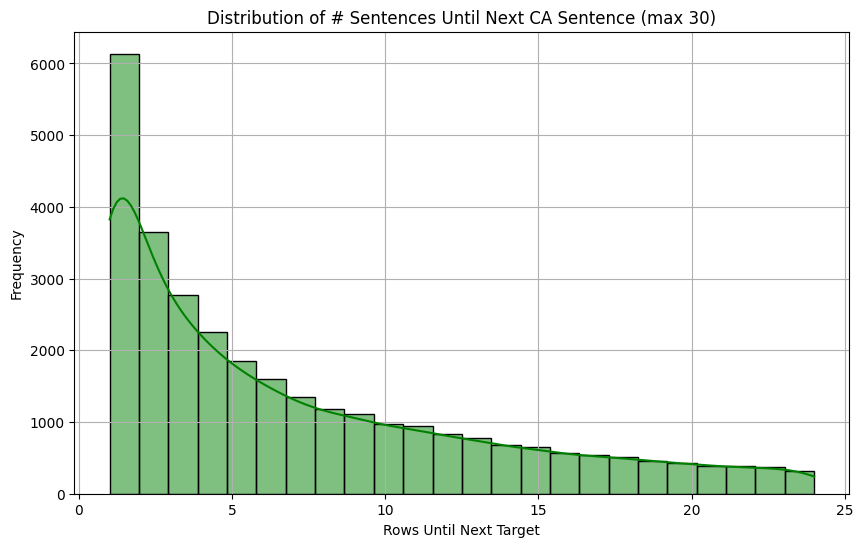

In [351]:
import seaborn as sns

import matplotlib.pyplot as plt

# Filter the rows where 'rows_until_next' is less than 1000
filtered_rows = new_df[new_df['rows_until_next'] < 25]

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(filtered_rows['rows_until_next'].dropna(), kde=True, bins = 24, color='green', edgecolor='black')
plt.xlabel('Rows Until Next Target')
plt.ylabel('Frequency')
plt.title('Distribution of # Sentences Until Next CA Sentence (max 30)')
plt.grid(True)
plt.show()

In [332]:
nan_count = new_df['rows_until_next'].isna().sum()
print(f'Number of NaN values in rows_until_next: {nan_count}')

Number of NaN values in rows_until_next: 8173


In [302]:
next_is_target_true_count = new_df['next_is_target'].sum()
print(f'Number of next_is_target that are True: {next_is_target_true_count}')

Number of next_is_target that are True: 6136


In [303]:
# Filter rows where next_is_target is True and next_next_is_target is True
filtered_rows = new_df[(new_df['next_is_target'] == True) & (new_df['next_next_is_target'] == True)]

# Count the number of such rows
count = len(filtered_rows)
print(f'Number of rows where next_is_target and next_next_is_target are both True: {count}')

Number of rows where next_is_target and next_next_is_target are both True: 1482


In [304]:
# Filter rows where next_is_target, next_next_is_target, and next_next_next_is_target are all True
filtered_rows_all_true = new_df[(new_df['next_is_target'] == True) & 
                                (new_df['next_next_is_target'] == True) & 
                                (new_df['next_next_next_is_target'] == True)]

# Count the number of such rows
count_all_true = len(filtered_rows_all_true)
print(f'Number of rows where next_is_target, next_next_is_target, and next_next_next_is_target are all True: {count_all_true}')

Number of rows where next_is_target, next_next_is_target, and next_next_next_is_target are all True: 686


In [325]:
import pandas as pd
import glob
import os

# List of all files
files = [file for i in range(1, 11) for file in glob.glob(f"../data/episodes/part_{i}/*.csv")]

# Initialize an empty list to store results
streak_results = []

# Loop over all files
for file in files:
    # Load the CSV file into a DataFrame
    df = pd.read_csv(file)
    
    # Identify target rows (collectiveAction = 0 and racialJustice = 1)
    target_rows = df[(df['collectiveAction'] == 0) & (df['racialJustice'] == 1)].index
    
    # Initialize variables to track streaks
    streak_length = 0
    episode_id = os.path.basename(file)  # Use the file name as the episode identifier
    
    for idx in range(len(df)):
        # Check if the current row is a target row
        if idx in target_rows:
            streak_length += 1  # Increment the streak length if it is a target row
        else:
            if streak_length > 1:  # Only consider streaks longer than 1
                # Record the streak length if it ended
                streak_results.append({'episode_id': episode_id, 'streak_length': streak_length})
            streak_length = 0  # Reset streak length when a non-target row is encountered

    # If there was a streak that ended at the last row, add it (if streak is longer than 1)
    if streak_length > 1:
        streak_results.append({'episode_id': episode_id, 'streak_length': streak_length})

# Create a new DataFrame from the streak results
streak_df = pd.DataFrame(streak_results)

# Display the new DataFrame
streak_df

,episode_id,streak_length
0,episode_1105.csv,2
1,episode_1475.csv,2
2,episode_10164.csv,2
3,episode_1267.csv,2
4,episode_113.csv,3
...,...,...
4649,episode_9839.csv,3
4650,episode_9554.csv,2
4651,episode_9597.csv,3
4652,episode_9597.csv,2


In [370]:
# Find the episode_id with streak_length over 50
episode_with_long_streak = streak_df[streak_df['streak_length'] > 50]['episode_id'].values[0]

# Construct the file path
file_path = f"../data/episodes/part_2/episode_1771.csv"

# Read the CSV file
episode_data = pd.read_csv(file_path)

# Display the first few rows of the episode data
episode_data.head(290)

,sentence,classification,annotator1,annotator2,annotator3,collectiveAction,racialJustice,collectiveActionMulti
0,"[MUSIC] Welcome to the Race Bridge, a podcast...",NaN,NaN,NaN,NaN,0,1,1.0
1,"[MUSIC] So welcome friends, right now we are t...",NaN,NaN,NaN,NaN,1,0,NaN
2,"So I'm your host, Chris Luster, welcome.",NaN,NaN,NaN,NaN,1,0,NaN
3,"If you have not already, definitely check out ...",NaN,NaN,NaN,NaN,1,0,NaN
4,And so I'm just really excited to have my seco...,NaN,NaN,NaN,NaN,1,0,NaN
...,...,...,...,...,...,...,...,...
285,And then I'm going to be a black man.,NaN,NaN,NaN,NaN,0,1,0.0
286,I'm going to be a black man.,NaN,NaN,NaN,NaN,0,1,2.0
287,And then I'm going to be a black man.,NaN,NaN,NaN,NaN,0,1,0.0
288,And then I'm going to be a black man.,NaN,NaN,NaN,NaN,0,1,0.0


In [331]:
# Calculate the number of streaks per episode_id
streak_counts = streak_df['episode_id'].value_counts()

# Calculate summary statistics
summary_stats = streak_counts.describe()

# Print the summary statistics
print(summary_stats)

count    2677.000000
mean        1.738513
std         1.324564
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        16.000000
Name: count, dtype: float64


In [329]:
# Filter rows where streak_length is greater than 5
streak_length_gt_5 = streak_df[streak_df['streak_length'] > 5]

# Count the number of such rows
count_gt_5 = len(streak_length_gt_5)
print(f'Number of rows with streak_length greater than 5: {count_gt_5}')

Number of rows with streak_length greater than 5: 21


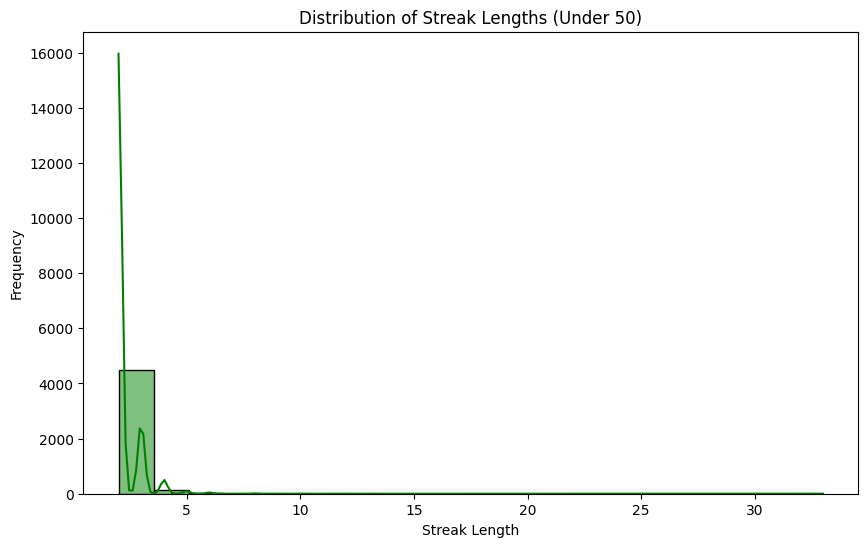

In [316]:
streak_df = pd.DataFrame(streak_results)

# Filter the streak_df to keep only streak lengths under 50
streak_df = streak_df[streak_df['streak_length'] < 50]

# Plot the distribution of streak_length
plt.figure(figsize=(10, 6))
sns.histplot(streak_df['streak_length'], kde=True, bins=20, color='green')
plt.title('Distribution of Streak Lengths (Under 50)')
plt.xlabel('Streak Length')
plt.ylabel('Frequency')
plt.show()

In [318]:
import pandas as pd
import glob
import os

# List of all files
files = [file for i in range(1, 11) for file in glob.glob(f"../data/episodes/part_{i}/*.csv")]

# Initialize an empty list to store results
streak_results = []

# Loop over all files
for file in files:
    # Load the CSV file into a DataFrame
    df = pd.read_csv(file)
    
    # Identify target rows (collectiveAction = 0 and racialJustice = 1)
    target_rows = df[(df['collectiveAction'] == 0) & (df['racialJustice'] == 1)].index
    
    # Initialize variables to track streaks
    streak_length = 0
    episode_id = os.path.basename(file)  # Use the file name as the episode identifier
    gap_count = 0  # Count the number of non-target rows in between
    
    for idx in range(len(df)):
        if idx in target_rows:
            if gap_count <= 1:  # If the gap count is 1 or less, continue the streak
                streak_length += 1
            else:
                if streak_length > 1:  # Record the streak if it's longer than 1
                    streak_results.append({'episode_id': episode_id, 'streak_length': streak_length})
                streak_length = 1  # Start a new streak with this target row
            gap_count = 0  # Reset gap count after a target row
        else:
            gap_count += 1  # Increment the gap count for non-target rows

    # Add the last streak if it's valid
    if streak_length > 1:
        streak_results.append({'episode_id': episode_id, 'streak_length': streak_length})

# Create a new DataFrame from the streak results
streak_df = pd.DataFrame(streak_results)

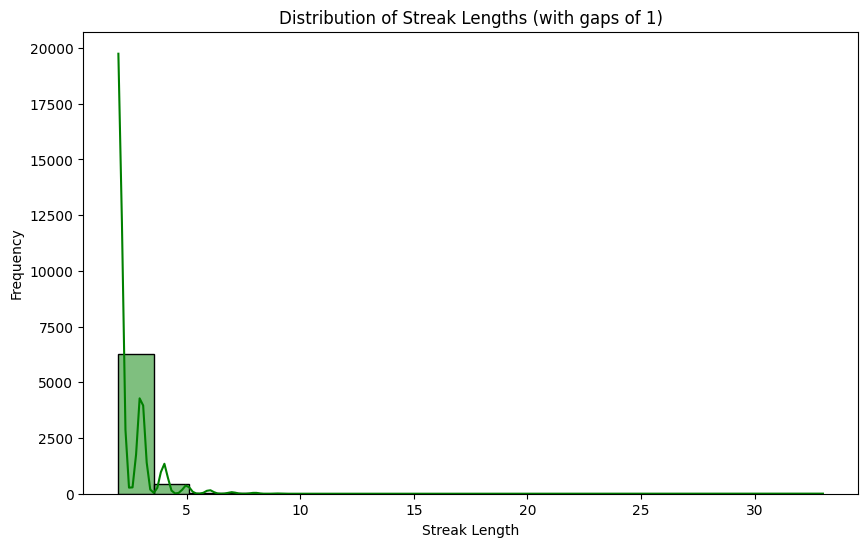

In [321]:
streak_df = pd.DataFrame(streak_results)

# Filter the streak_df to keep only streak lengths under 50
streak_df = streak_df[streak_df['streak_length'] < 50]

# Plot the distribution of streak_length
plt.figure(figsize=(10, 6))
sns.histplot(streak_df['streak_length'], kde=True, bins=20, color='green')
plt.title('Distribution of Streak Lengths (with gaps of 1)')
plt.xlabel('Streak Length')
plt.ylabel('Frequency')
plt.show()

In [322]:
import pandas as pd
import glob
import os

# List of all files
files = [file for i in range(1, 11) for file in glob.glob(f"../data/episodes/part_{i}/*.csv")]

# Initialize an empty list to store results
streak_results = []

# Loop over all files
for file in files:
    # Load the CSV file into a DataFrame
    df = pd.read_csv(file)
    
    # Identify target rows (collectiveAction = 0 and racialJustice = 1)
    target_rows = df[(df['collectiveAction'] == 0) & (df['racialJustice'] == 1)].index
    
    # Initialize variables to track streaks
    streak_length = 0
    episode_id = os.path.basename(file)  # Use the file name as the episode identifier
    gap_count = 0  # Count the number of non-target rows in between
    
    for idx in range(len(df)):
        if idx in target_rows:
            if gap_count <= 2:  # If the gap count is 2 or less, continue the streak
                streak_length += 1
            else:
                if streak_length > 1:  # Record the streak if it's longer than 1
                    streak_results.append({'episode_id': episode_id, 'streak_length': streak_length})
                streak_length = 1  # Start a new streak with this target row
            gap_count = 0  # Reset gap count after a target row
        else:
            gap_count += 1  # Increment the gap count for non-target rows

    # Add the last streak if it's valid
    if streak_length > 1:
        streak_results.append({'episode_id': episode_id, 'streak_length': streak_length})

# Create a new DataFrame from the streak results
streak_df = pd.DataFrame(streak_results)

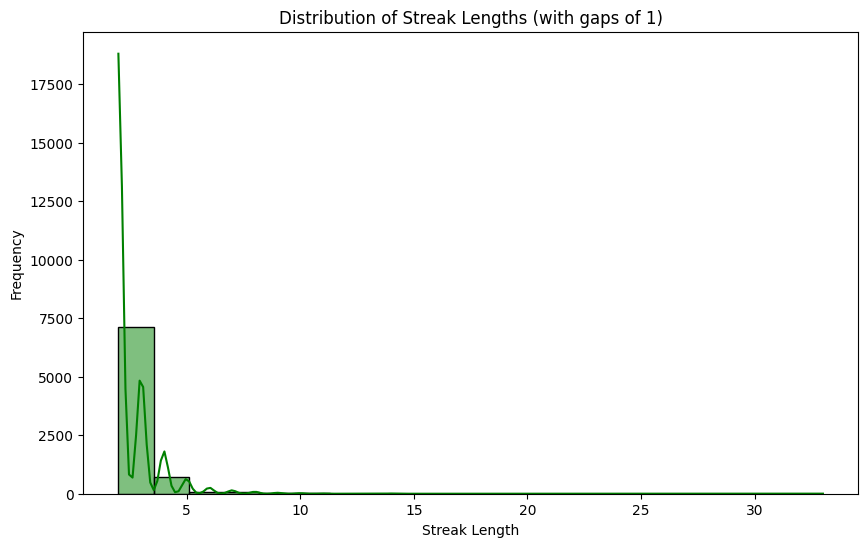

In [ ]:
streak_df = pd.DataFrame(streak_results)

# Filter the streak_df to keep only streak lengths under 50
streak_df = streak_df[streak_df['streak_length'] < 50]

# Plot the distribution of streak_length
plt.figure(figsize=(10, 6))
sns.histplot(streak_df['streak_length'], kde=True, bins=20, color='green')
plt.title('Distribution of Streak Lengths (with gaps of 2)')
plt.xlabel('Streak Length')
plt.ylabel('Frequency')
plt.show()

In [352]:
import pandas as pd
import glob
import os

# List of all files
files = [file for i in range(1, 11) for file in glob.glob(f"../data/episodes/part_{i}/*.csv")]

# Initialize lists to store streak lengths
pure_ca_streaks = []
mixed_ca_streaks = []

# Loop over all files
for file in files:
    df = pd.read_csv(file)

    # Identify target rows where racialJustice == 1
    target_rows = df[df['racialJustice'] == 1]
    
    # Track streaks
    streak_length = 0
    has_ca_0 = False
    episode_id = os.path.basename(file)  # Use file name as episode identifier

    for idx, row in target_rows.iterrows():
        if streak_length == 0:
            # Start a new streak
            has_ca_0 = row['collectiveAction'] == 0
            streak_length = 1
        else:
            # Check if we are still in a streak
            if idx == target_rows.index[streak_length - 1] + 1:
                streak_length += 1
                if row['collectiveAction'] == 0:
                    has_ca_0 = True
            else:
                # Streak ended, record it
                if streak_length > 1:
                    if has_ca_0:
                        mixed_ca_streaks.append(streak_length)
                    else:
                        pure_ca_streaks.append(streak_length)
                
                # Start a new streak
                has_ca_0 = row['collectiveAction'] == 0
                streak_length = 1

    # Add the last streak if it was valid
    if streak_length > 1:
        if has_ca_0:
            mixed_ca_streaks.append(streak_length)
        else:
            pure_ca_streaks.append(streak_length)

# Compute average lengths
avg_pure_ca_streak = sum(pure_ca_streaks) / len(pure_ca_streaks) if pure_ca_streaks else 0
avg_mixed_ca_streak = sum(mixed_ca_streaks) / len(mixed_ca_streaks) if mixed_ca_streaks else 0

print(f"Average Pure CA Streak Length: {avg_pure_ca_streak:.2f}")
print(f"Average Mixed CA Streak Length: {avg_mixed_ca_streak:.2f}")

Average Pure CA Streak Length: 2.25
Average Mixed CA Streak Length: 2.47


In [ ]:
# Count the number of unique categories in numMainSpeakers
num_main_speakers_counts = filtered_episodes['numMainSpeakers'].value_counts()
num_main_speakers_counts

numMainSpeakers
1.0     3524
2.0     3281
3.0      875
4.0      284
5.0       98
6.0       44
7.0       18
8.0        2
10.0       1
Name: count, dtype: int64

### Speaker turns

In [383]:
import pandas as pd
import glob

# Get the list of all CSV files in the directory
csv_files = glob.glob("../data/speaker_turns/*.csv")

# Initialize a counter for files with the column 'collectiveActionMulti'
count_collective_action_multi = 0

# Loop through each file and check for the column 'collectiveActionMulti'
for file in csv_files:
    df = pd.read_csv(file)
    if 'collectiveActionMulti' in df.columns:
        count_collective_action_multi += 1

# Print the results
print(f'Number of files with the column "collectiveActionMulti": {count_collective_action_multi}')

Number of files with the column "collectiveActionMulti": 0


### Compute accuracy and confusion matrix on racial justice subset

In [137]:
# Initialize an empty list to store dataframes
all_data = []

# Loop through all parts and read CSV files
for i in range(1, 11):
    files = glob.glob(f"../data/episodes/part_{i}/*.csv")
    for file_path in files:
        df = pd.read_csv(file_path)
        all_data.append(df)

# Concatenate all dataframes into a single dataframe
all_df = pd.concat(all_data, ignore_index=True)

# Filter rows where racialJustice is equal to 1
racial_all = all_df[all_df['racialJustice'] == 1]

# Display the first few rows of the filtered dataframe
racial_all.head()

,sentence,classification,annotator1,annotator2,annotator3,collectiveAction,racialJustice
45,"But in terms of police brutality, injustices, racial or otherwise, just injustice period.",NaN,NaN,NaN,NaN,1,1
50,"And I read up on history and black literature, African American literature, African literature, I read up on the struggle.",NaN,NaN,NaN,NaN,0,1
65,"I don't remember everything from black studies, African American history, literature, black, world, studies, African diaspora.",NaN,NaN,NaN,NaN,1,1
74,"And he had said something about and don't quote me on this, but something about, I don't know, white devil, blue eyes.",NaN,NaN,NaN,NaN,1,1
84,"And so anyway, yeah, in black studies in high school, but I've also seen the movie and I've also seen countless fucking documentaries.",NaN,NaN,NaN,NaN,1,1


In [138]:
#annotation_set_race_majority = pd.read_csv("../data/annotation_set_race_majority.csv")
annotation_set_action_majority = pd.read_csv("../data/annotation_set_action_majority.csv")
common_action = pd.merge(annotation_set_action_majority, racial_all, on='sentence')
common_action = common_action[['sentence', 'majority', 'collectiveAction']]

In [139]:
len(common_action)

19

In [140]:
new_sample_action_theodora = pd.read_csv("../data/new_sample_action_theodora.csv")
new_sample_action_arianna = pd.read_csv("../data/new_sample_action_arianna.csv")
new_sample_action_davide = pd.read_csv("../data/new_sample_action_davide.csv")
new_sample_action_labels = pd.read_csv("../data/new_sample_action_labels.csv")

In [141]:
new_sample_action = new_sample_action_arianna[['sentence', 'annotator1', 'note']]
new_sample_action['theodora'] = new_sample_action_theodora['annotator3']
new_sample_action['davide'] = new_sample_action_davide['annotator1']
new_sample_action = new_sample_action[['sentence', 'annotator1', 'theodora', 'davide', 'note']]
def majority_vote(row):
    return row.mode().iloc[0] if not row.mode().empty else None
new_sample_action['majority'] = new_sample_action[['annotator1', 'theodora', 'davide']].apply(majority_vote, axis=1)
new_sample_action['collectiveAction'] = new_sample_action_labels['collectiveAction']
new_sample_action = pd.concat([new_sample_action, common_action], ignore_index=True)
new_sample_action['collectiveAction'].head()

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_87000/461094631.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_sample_action['theodora'] = new_sample_action_theodora['annotator3']


0    1
1    1
2    1
3    1
4    1
Name: collectiveAction, dtype: int64

In [ ]:
# # Filter rows where annotator1, theodora, and davide columns are not the same
# discrepant_rows = new_sample_action[(new_sample_action['annotator1'] != new_sample_action['theodora']) | 
#                                     (new_sample_action['annotator1'] != new_sample_action['davide']) | 
#                                     (new_sample_action['theodora'] != new_sample_action['davide'])]

# discrepant_rows

In [143]:
new_sample_action['collectiveAction'] = 1 - new_sample_action['collectiveAction']
new_sample_action['collectiveAction'].head()

0    0
1    0
2    0
3    0
4    0
Name: collectiveAction, dtype: int64

In [144]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Compute accuracy
accuracy = accuracy_score(new_sample_action['collectiveAction'], new_sample_action['majority'])

# Compute confusion matrix
tn, fp, fn, tp = confusion_matrix(new_sample_action['majority'], new_sample_action['collectiveAction']).ravel()

# Print results
print(f'Accuracy: {accuracy:.4f}')
print(f'True Positives (TP): {tp}')
print(f'True Negatives (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')

Accuracy: 0.7100
True Positives (TP): 39
True Negatives (TN): 32
False Positives (FP): 11
False Negatives (FN): 18


In [145]:
false_positives = new_sample_action[(new_sample_action['collectiveAction'] == 1) & (new_sample_action['majority'] == 0)]
false_positives

,sentence,annotator1,theodora,davide,note,majority,collectiveAction
50,Black lives understand their history so much more than a good majority of lives out there.,0.0,0.0,0.0,NaN,0.0,1
51,"I mean, and it's every day black folks that's out here just minding their own business.",0.0,0.0,0.0,NaN,0.0,1
54,"Like, I'm seeing a lot of people who are showing their support to the Black Lives Matter movement.",0.0,0.0,0.0,does not show involvement of speaker,0.0,1
62,But you see the Hispanics don't listen to none of them.,0.0,0.0,1.0,NaN,0.0,1
74,The Democrats were the party of the KKK.,0.0,0.0,0.0,"just going against political party, not a problem recognition itself",0.0,1
77,"Good, Godly loving African-American women.",0.0,0.0,0.0,NaN,0.0,1
79,"I said, well, for all the white people they're gonna need to know who this guy is and where he went to school and what his degrees are.",0.0,0.0,1.0,NaN,0.0,1
81,There is speculation that Mr. Trump might speak to the nation about racial injustice and the need to do better.,NaN,NaN,NaN,NaN,0.0,1
85,It doesn't matter how black people are showing up against racism in this country.,NaN,NaN,NaN,NaN,0.0,1
95,One of the things I want to come on here and talk about because I'm a black man who watches shows and I watch the Young and the Restless.,NaN,NaN,NaN,NaN,0.0,1


In [146]:
import krippendorff
import numpy as np
import pandas as pd

valid_values = {0, 1}

# Convert all columns to numeric (coerce errors to NaN)
new_sample_action[['davide', 'annotator1', 'theodora']] = new_sample_action[['davide', 'annotator1', 'theodora']].apply(pd.to_numeric, errors='coerce')

# Drop rows that contain invalid values (anything other than 0 or 1)
filtered_data = new_sample_action.dropna(subset=['davide', 'annotator1', 'theodora'])
filtered_data = filtered_data[
    filtered_data[['davide', 'annotator1', 'theodora']].applymap(lambda x: x in valid_values).all(axis=1)
]

data = filtered_data[['davide', 'annotator1', 'theodora']].to_numpy(dtype=int).T
alpha = krippendorff.alpha(reliability_data=data, level_of_measurement='nominal')
print(f"Krippendorff's alpha: {alpha:.4f}")

Krippendorff's alpha: 0.5473


/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_87000/342566595.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  filtered_data[['davide', 'annotator1', 'theodora']].applymap(lambda x: x in valid_values).all(axis=1)
